# 05 Vergleich - ARIMA, TFT und Chronos-2

## Ziel

Dieses Notebook vergleicht die Punkt- und, soweit verfügbar, probabilistischen Prognosen von **ARIMA**, **Temporal Fusion Transformer (TFT)** und **Chronos-2** mit der gemeinsamen Baseline **Random Walk mit Drift**.

## Inhaltsverzeichnis

1. [Setup und gemeinsame Evaluationsbasis](#1-setup-und-gemeinsame-evaluationsbasis)
2. [Gesamtvergleich und Nutzen gegenüber der Baseline](#2-gesamtvergleich-und-nutzen-gegenueber-der-baseline)
3. [Durchschnittlicher Verlauf und Länderbeispiele](#3-durchschnittlicher-verlauf-und-laenderbeispiele)
4. [Prognosequalität nach Horizont und Backtest-Fold](#4-prognosequalitaet-nach-horizont-und-backtest-fold)
5. [MASE nach Region und Einkommensgruppe](#5-mase-nach-region-und-einkommensgruppe)
6. [Residualdiagnostik](#6-residualdiagnostik)
7. [Unsicherheitsintervalle und statistische Tests](#7-unsicherheitsintervalle-und-statistische-tests)
8. [Fazit](#8-fazit)

## 1 Setup und gemeinsame Evaluationsbasis

Die Ergebnisdateien folgen dem gemeinsamen Schema aus den Modellnotebooks. Vor jeder Auswertung wird geprüft, ob die Modelle exakt dieselben Kombinationen aus Land, Forecast-Origin, Zieljahr und Horizont enthalten. Dadurch entstehen keine scheinbaren Unterschiede durch abweichende Datenabdeckung.

**Interpretation der Metriken:** MASE ist die Primärmetrik, weil sie pro Land mit dem Fehler einer naiven Ein-Schritt-Prognose skaliert wird und daher über unterschiedlich volatile Länder vergleichbar ist. Werte unter 1 bedeuten einen geringeren Fehler als diese naive Referenz. RMSE und MAE ergänzen die Sicht in Prozentpunkten BIP-Wachstum.

In [1]:
from pathlib import Path
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Notebook sowohl aus dem Repository-Root als auch aus CapstoneProjekt_BPI starten können.
root = Path.cwd()
if (root / "CapstoneProjekt_BPI").exists():
    root = root / "CapstoneProjekt_BPI"
if not (root / "src").exists():
    raise FileNotFoundError("CapstoneProjekt_BPI mit dem Ordner 'src' wurde nicht gefunden.")
os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src import config, data_utils, evaluation, plotting

warnings.filterwarnings("ignore", category=FutureWarning)
plotting.apply_style()

panel = data_utils.load_panel()
static = pd.read_csv(config.PROCESSED_DIR / "countries_static.csv")
preds = evaluation.load_all_predictions()

model_order = ["rw_drift", "arima", "tft", "chronos2"]
missing_models = set(model_order).difference(preds["model"].unique())
if missing_models:
    raise ValueError(f"Ergebnisdateien fehlen für: {sorted(missing_models)}")
preds = preds[preds["model"].isin(model_order)].copy()
holdout = preds[preds["origin_year"] == config.FINAL_ORIGIN].copy()

key_cols = ["country", "origin_year", "year", "h"]
key_sets = {
    model: set(map(tuple, frame[key_cols].to_numpy()))
    for model, frame in preds.groupby("model")
}
reference_keys = key_sets[model_order[0]]
if any(keys != reference_keys for keys in key_sets.values()):
    raise ValueError("Die Modelle enthalten nicht dieselben Prognose-Keys.")
if preds[["y_true", "y_pred"]].isna().any().any():
    raise ValueError("Für die Vergleichsauswertung fehlen Ist- oder Prognosewerte.")

print(
    f"Vergleichsbasis: {len(reference_keys):,} Prognosen je Modell | "
    f"{preds['country'].nunique()} Länder | "
    f"Origins {sorted(preds['origin_year'].unique())} | "
    f"Horizonte {sorted(preds['h'].unique())}"
 )
display(
    preds.groupby("model").agg(
        Prognosen=("y_pred", "size"),
        Länder=("country", "nunique"),
        Intervalle_q10_q90=("q10", lambda values: int(values.notna().sum())),
    ).reindex(model_order)
 )

Vergleichsbasis: 2,900 Prognosen je Modell | 116 Länder | Origins [np.int64(1999), np.int64(2004), np.int64(2009), np.int64(2014), np.int64(2019)] | Horizonte [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,Prognosen,Länder,Intervalle_q10_q90
model,,,
rw_drift,2900,116,0
arima,2900,116,0
tft,2900,116,2900
chronos2,2900,116,2900


In [2]:
MODEL_LABELS = config.MODEL_NAMES.copy()
MODEL_LABELS["rw_drift"] = "Baseline"
MODEL_LABELS["tft"] = "TFT"
MODEL_LABELS["chronos2"] = "Chronos-2"
MODEL_COLORS = {model: plotting.MODEL_COLORS[model] for model in model_order}


def with_model_label(frame: pd.DataFrame) -> pd.DataFrame:
    """Ergänzt eine sortierbare deutschsprachige Modellbezeichnung."""
    result = frame.copy()
    result["Modell"] = pd.Categorical(
        result["model"].map(MODEL_LABELS),
        categories=[MODEL_LABELS[model] for model in model_order],
        ordered=True,
    )
    return result


def country_origin_mase(frame: pd.DataFrame) -> pd.DataFrame:
    """MASE je Modell, Land und Forecast-Origin berechnen."""
    rows = []
    for (model, country, origin), group in frame.groupby(
        ["model", "country", "origin_year"], sort=False
    ):
        training_values = panel.loc[
            (panel["country"] == country) & (panel["year"] <= origin),
            config.TARGET,
        ]
        rows.append({
            "model": model,
            "country": country,
            "origin_year": origin,
            "MASE": evaluation.mase(group["y_true"], group["y_pred"], training_values),
        })
    return pd.DataFrame(rows)


def scaled_errors_by_horizon(frame: pd.DataFrame) -> pd.DataFrame:
    """Absoluten Fehler mit dem land- und originspezifischen Naivfehler skalieren."""
    rows = []
    for (model, country, origin), group in frame.groupby(
        ["model", "country", "origin_year"], sort=False
    ):
        training_values = panel.loc[
            (panel["country"] == country) & (panel["year"] <= origin),
            config.TARGET,
        ].dropna().to_numpy(float)
        scale = np.mean(np.abs(np.diff(training_values))) if len(training_values) >= 2 else np.nan
        if not np.isfinite(scale) or scale == 0:
            continue
        for row in group.itertuples(index=False):
            rows.append({
                "model": model,
                "country": country,
                "origin_year": origin,
                "h": row.h,
                "scaled_absolute_error": abs(row.y_true - row.y_pred) / scale,
            })
    return pd.DataFrame(rows)


def compare_against_baseline(metric_table: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Ergänzt die relative Änderung gegenüber Random Walk mit Drift."""
    result = metric_table.copy()
    baseline = result.loc[result["model"] == "rw_drift", metric].iloc[0]
    result[f"{metric}_vs_Baseline"] = 1 - result[metric] / baseline
    return result

mase_by_country_origin = country_origin_mase(preds)
scaled_errors = scaled_errors_by_horizon(preds)

## 2 Gesamtvergleich und Nutzen gegenueber der Baseline

Die folgende Tabelle fasst die gesamte Walk-Forward-Evaluation zusammen. MASE wird zunächst für jede Kombination aus Land und Origin bestimmt und anschließend gemittelt. Dadurch erhalten Länder mit besonders volatilen Wachstumsraten kein übermäßiges Gewicht.

Die Spalte **MASE vs. Baseline** zeigt die relative Verbesserung gegenüber Random Walk mit Drift. Positive Werte sind besser als die Baseline, negative Werte schlechter.

,Modell,MASE,MASE vs. Baseline,RMSE,MAE,pinball_q10,pinball_q90,80%-Abdeckung,Prognosen
0,Baseline,1.083,0.000,6.874,4.005,NaN,NaN,NaN,2900
1,ARIMA,0.840,0.225,5.336,3.105,NaN,NaN,NaN,2900
2,TFT,0.917,0.153,5.554,3.324,1.078,0.892,0.674,2900
3,Chronos-2,0.848,0.217,5.447,3.089,0.959,0.801,0.843,2900


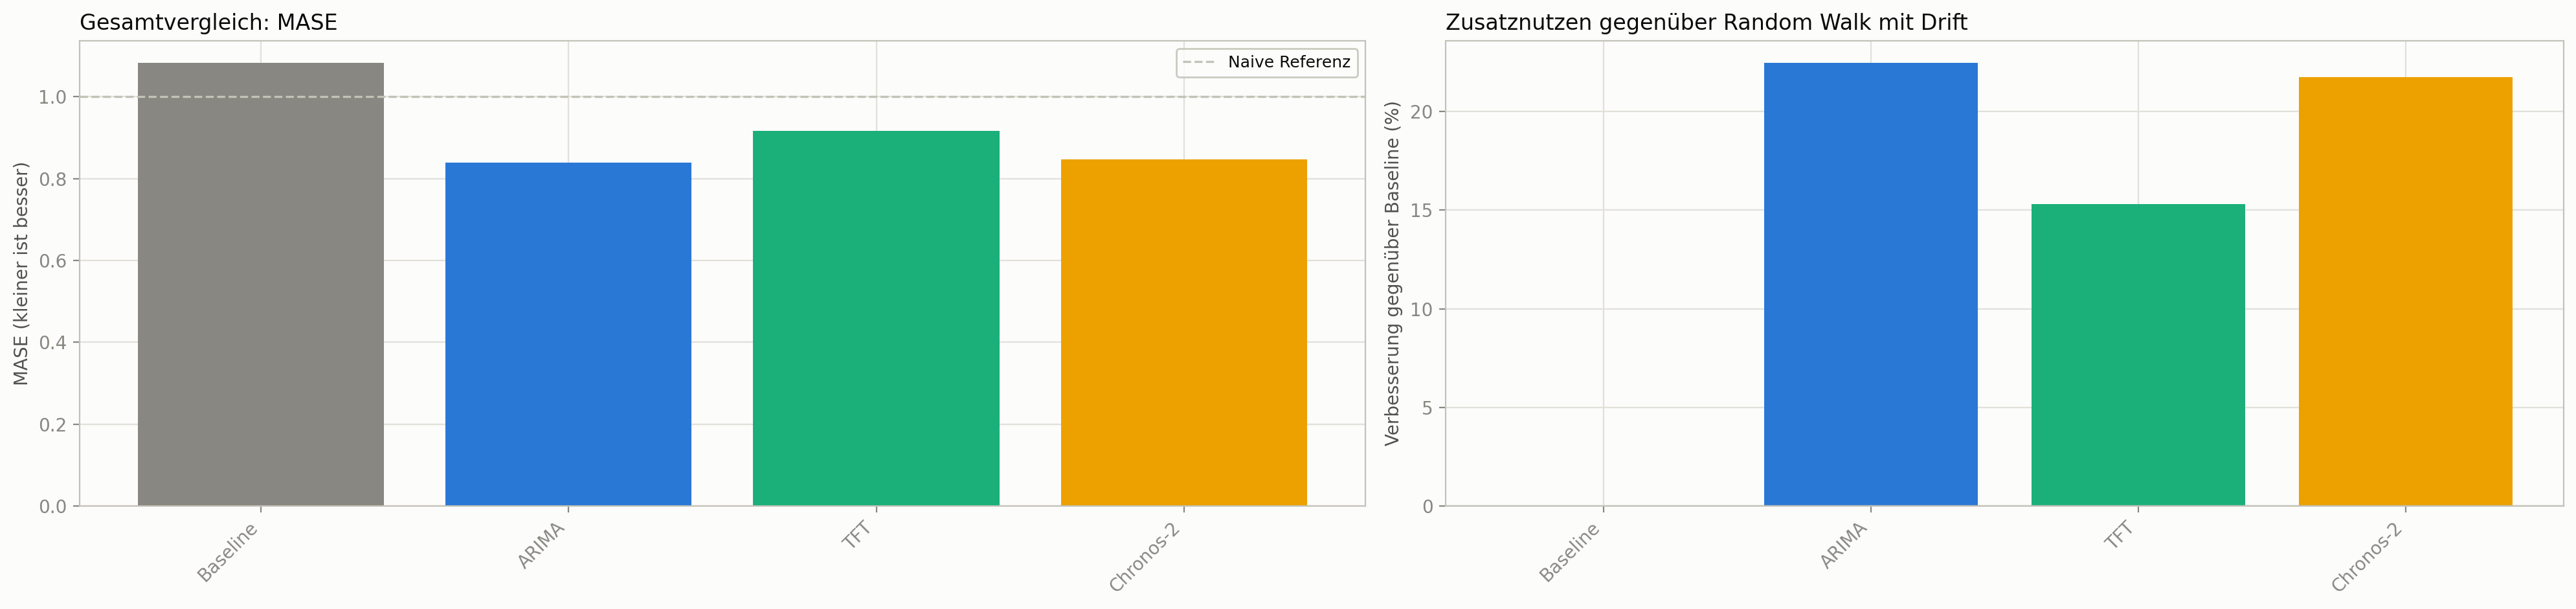

In [3]:
overall = evaluation.summarize(preds, panel).set_index("model").reindex(model_order).reset_index()
overall = compare_against_baseline(overall, "MASE")
overall["Modell"] = overall["model"].map(MODEL_LABELS)

display_cols = [
    "Modell", "MASE", "MASE_vs_Baseline", "RMSE", "MAE",
    "pinball_q10", "pinball_q90", "coverage_80", "n_forecasts",
]
display(
    overall[display_cols].rename(columns={
        "MASE_vs_Baseline": "MASE vs. Baseline",
        "coverage_80": "80%-Abdeckung",
        "n_forecasts": "Prognosen",
    }).round(3)
 )

fig, axes = plt.subplots(1, 2, figsize=(20, 4.8), gridspec_kw={"width_ratios": [1.15, 1]})
bar_models = overall["Modell"]
bar_positions = np.arange(len(bar_models))
axes[0].bar(bar_positions, overall["MASE"], color=[MODEL_COLORS[m] for m in overall["model"]])
axes[0].axhline(1, color=plotting.BASELINE, linewidth=1.2, linestyle="--", label="Naive Referenz")
axes[0].set_xticks(bar_positions, bar_models, rotation=45, ha="right")
axes[0].set_ylabel("MASE (kleiner ist besser)")
axes[0].set_title("Gesamtvergleich: MASE", loc="left")
plotting.add_legend(axes[0], loc="upper right")

axes[1].bar(
    bar_positions,
    overall["MASE_vs_Baseline"] * 100,
    color=[MODEL_COLORS[m] for m in overall["model"]],
 )
axes[1].axhline(0, color=plotting.BASELINE, linewidth=1.2)
axes[1].set_xticks(bar_positions, bar_models, rotation=45, ha="right")
axes[1].set_ylabel("Verbesserung gegenüber Baseline (%)")
axes[1].set_title("Zusatznutzen gegenüber Random Walk mit Drift", loc="left")
fig.tight_layout()
plt.show()

## 3 Durchschnittlicher Verlauf und Laenderbeispiele

### 3.1 Durchschnitt über alle Länder

Für den finalen, zuvor nicht zur Modellwahl verwendeten Holdout 2020–2024 wird der Mittelwert des BIP-Wachstums über Länder gezeigt. Jedes Land erhält dabei das gleiche Gewicht; es handelt sich also nicht um das weltweite, BIP-gewichtete Wachstum.

Die transparenten Bänder zeigen die **länderspezifische Streuung** als Mittelwert ± eine Standardabweichung über Länder. Sie beschreiben die Heterogenität des Länderpanels und sind keine modellinternen Prognoseintervalle. Die 80%-Intervalle von TFT und Chronos-2 werden separat in Abschnitt 7 bewertet.

Die Darstellung beantwortet, ob die Modelle die gemeinsame Dynamik über die Zeit treffen. Sie ersetzt keine länderspezifische Bewertung, weil positive und negative Fehler sich im Mittel aufheben können.

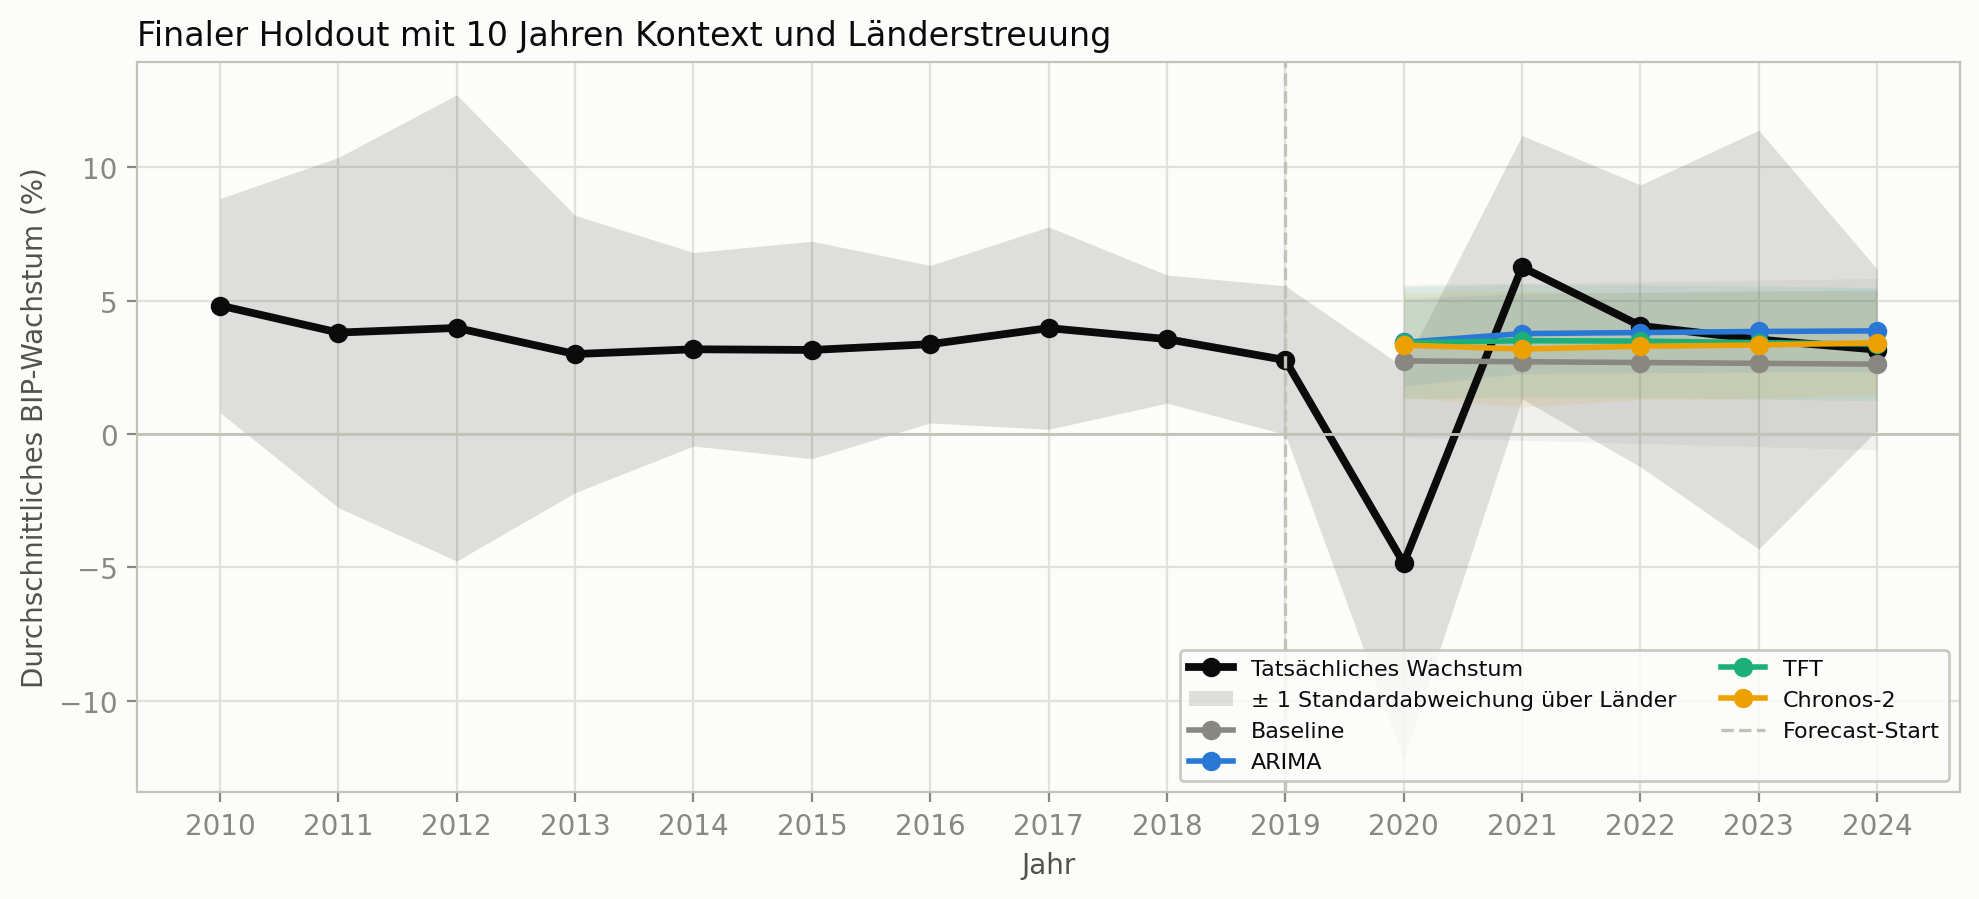

In [4]:
CONTEXT_YEARS = 10
context_start = config.FINAL_ORIGIN - CONTEXT_YEARS + 1
context_panel = panel[
    panel["year"].between(context_start, config.FINAL_ORIGIN + config.HORIZON)
].copy()
actual_stats = (
    context_panel.groupby("year")[config.TARGET]
    .agg(mean="mean", std="std")
    .reset_index()
 )
forecast_stats = (
    holdout.groupby(["model", "year"])["y_pred"]
    .agg(mean="mean", std="std")
    .reset_index()
 )

fig, ax = plt.subplots(figsize=(10, 4.6))
actual_color = plotting.MODEL_COLORS["actual"]
ax.plot(actual_stats["year"], actual_stats["mean"], color=actual_color,
        linewidth=2.8, marker="o", label="Tatsächliches Wachstum")
ax.fill_between(
    actual_stats["year"],
    actual_stats["mean"] - actual_stats["std"],
    actual_stats["mean"] + actual_stats["std"],
    color=actual_color, alpha=0.12, linewidth=0,
    label="± 1 Standardabweichung über Länder",
 )
for model in model_order:
    series = forecast_stats[forecast_stats["model"] == model]
    color = MODEL_COLORS[model]
    ax.plot(series["year"], series["mean"], color=color,
            linewidth=2, marker="o", label=MODEL_LABELS[model])
    ax.fill_between(
        series["year"],
        series["mean"] - series["std"],
        series["mean"] + series["std"],
        color=color, alpha=0.10, linewidth=0,
     )
ax.axvline(config.FINAL_ORIGIN, color=plotting.BASELINE, linewidth=1.2,
           linestyle="--", label="Forecast-Start")
ax.axhline(0, color=plotting.BASELINE, linewidth=1)
ax.set_xticks(sorted(actual_stats["year"]))
ax.set_xlabel("Jahr")
ax.set_ylabel("Durchschnittliches BIP-Wachstum (%)")
ax.set_title(
    f"Finaler Holdout mit {CONTEXT_YEARS} Jahren Kontext und Länderstreuung",
    loc="left",
 )
plotting.add_legend(ax, ncol=2, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

### 3.2 Länderbeispiele

Die vier Beispiele sollen unterschiedliche Regionen und Entwicklungsniveaus abdecken. Die schwarze Linie enthält die beobachtete Historie und die realisierten Testwerte; farbige Linien zeigen die Prognosen aus dem finalen Holdout. Schattierungen markieren die 80%-Intervalle, sofern das Modell sie bereitstellt.

Die Fallstudien sind illustrativ. Für die allgemeine Güte bleiben die aggregierten, ländergleich gewichteten MASE-Auswertungen maßgeblich.

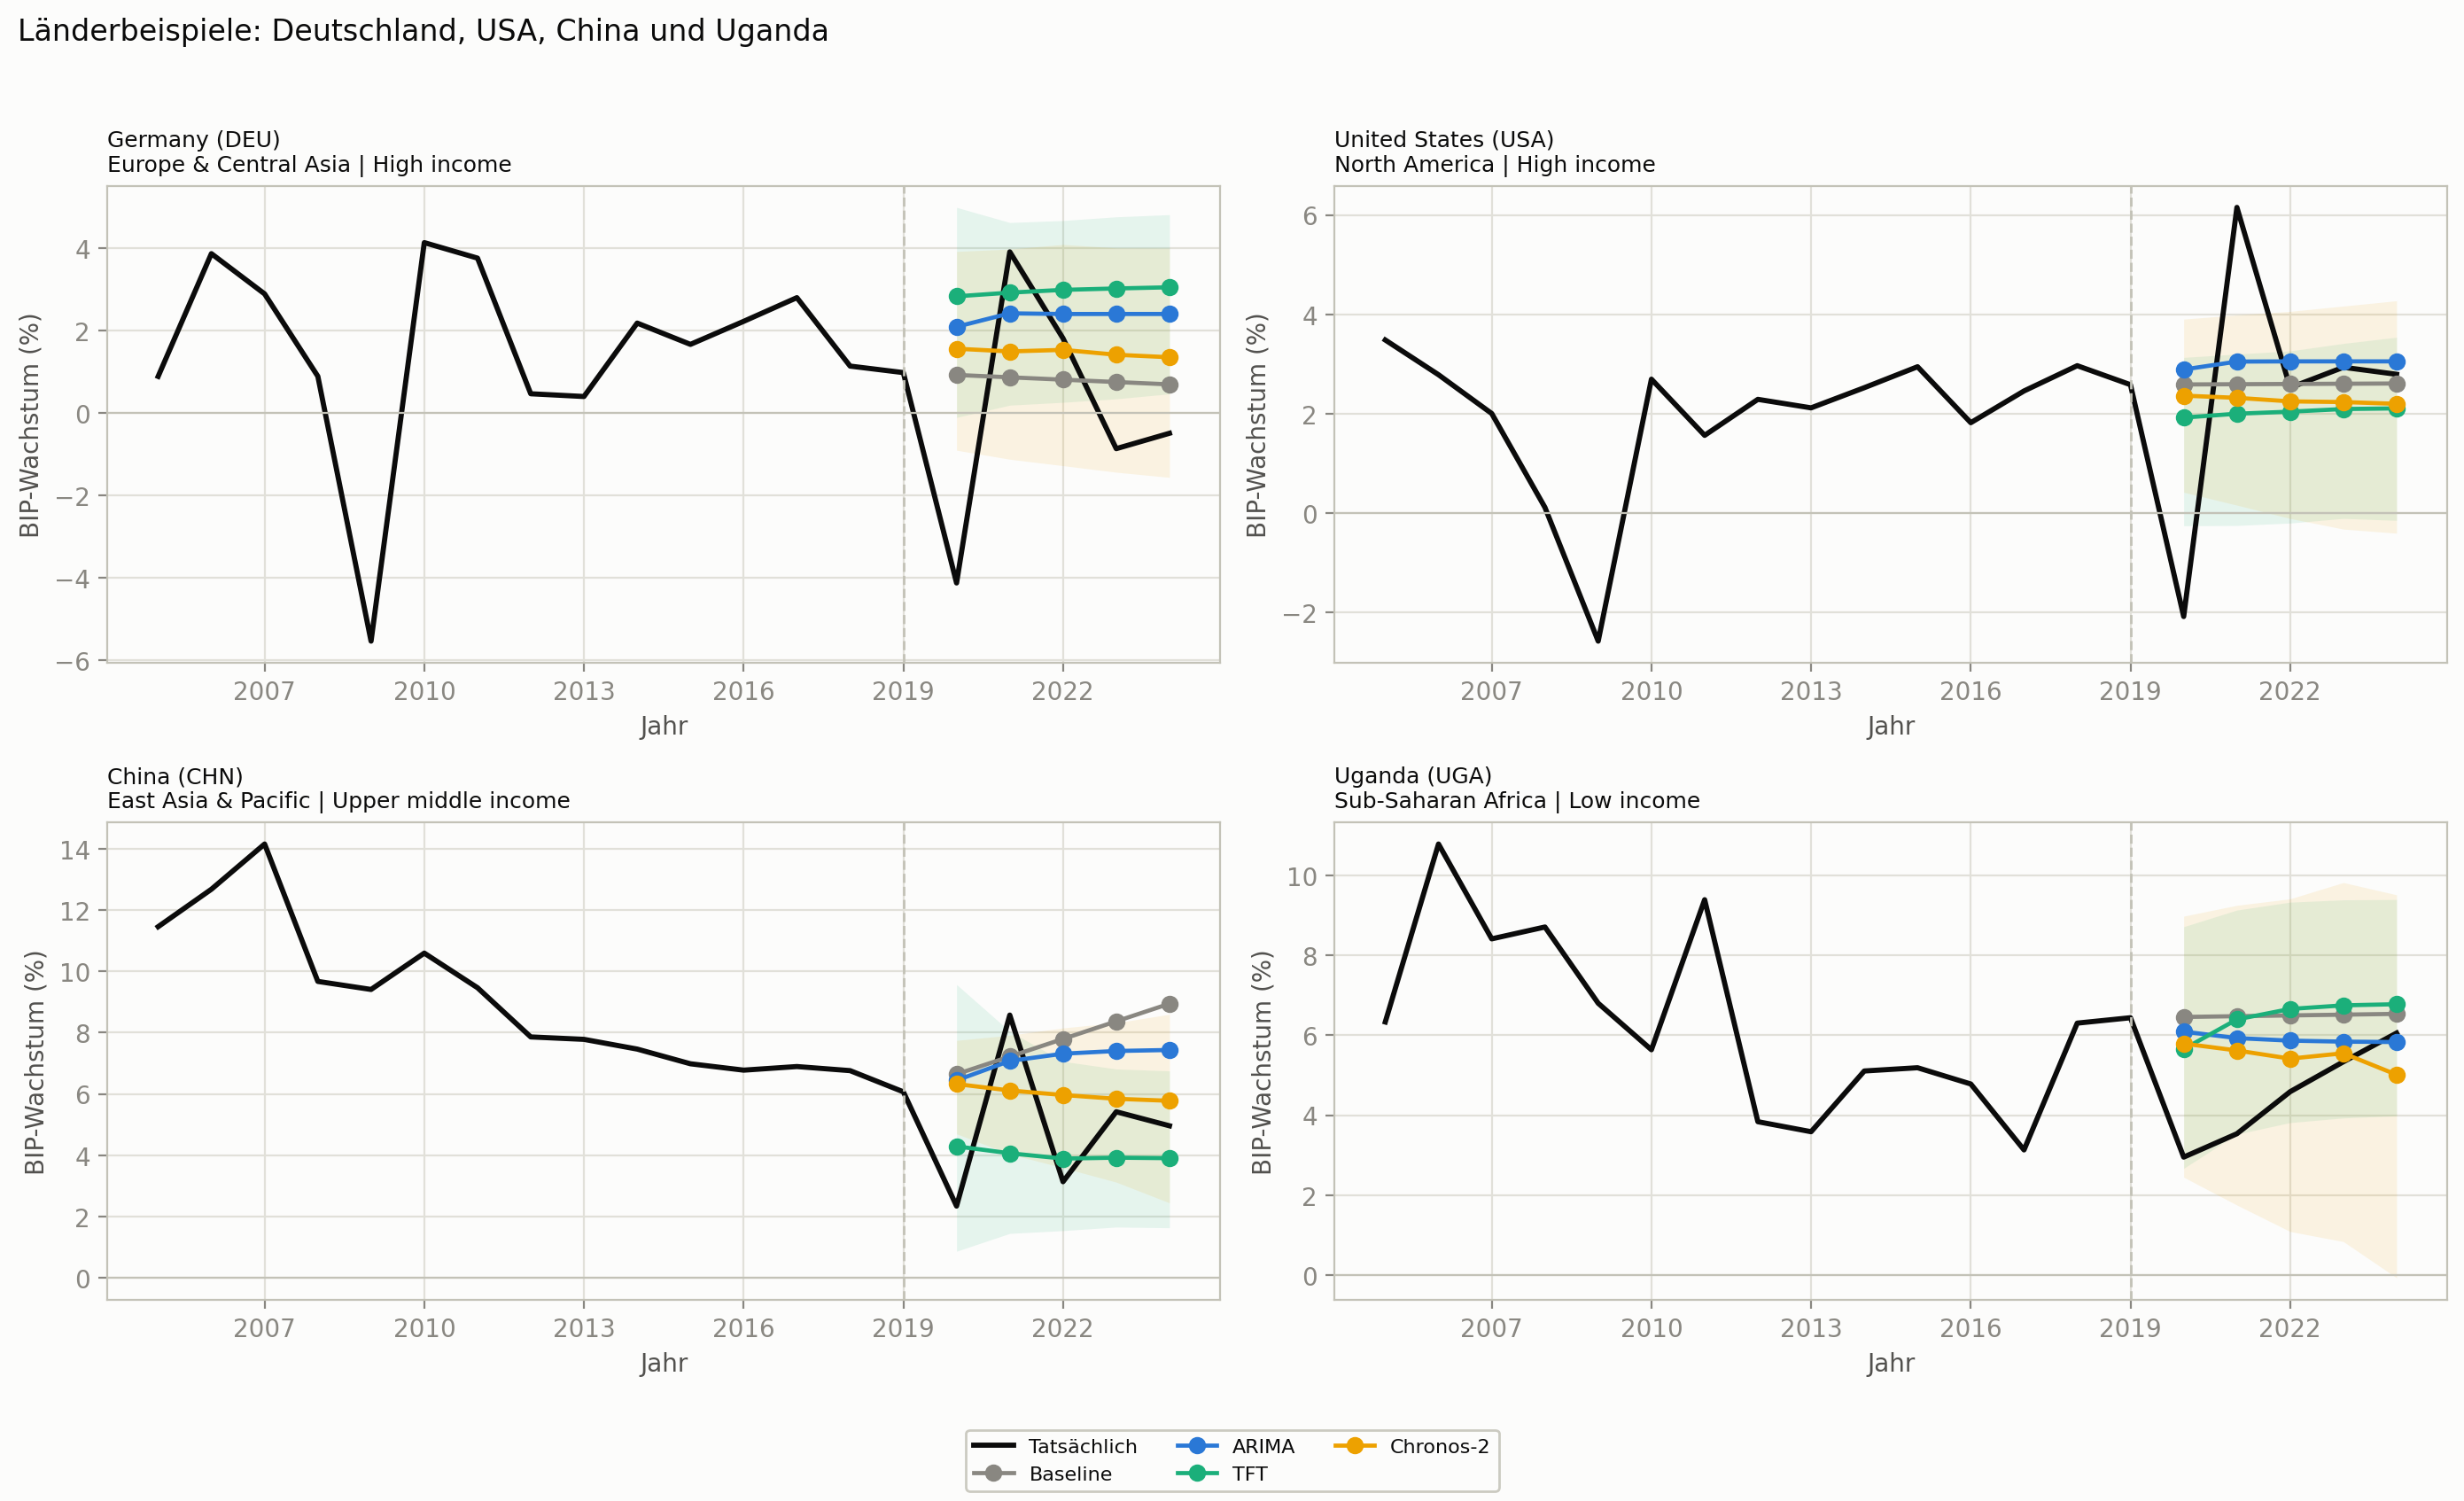

In [5]:
requested_countries = ["DEU", "USA", "CHN", "UGA"]
available_countries = set(panel["country"])
missing_countries = sorted(set(requested_countries).difference(available_countries))
if missing_countries:
    raise ValueError(f"Beispielländer fehlen im Panel: {missing_countries}")
example_countries = requested_countries

from matplotlib.ticker import MaxNLocator

country_info = static.set_index("country")
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5), sharex=False)
for ax, country in zip(axes.ravel(), example_countries):
    history = panel[
        (panel["country"] == country) & (panel["year"] >= 2005)
    ].sort_values("year")
    country_holdout = holdout[holdout["country"] == country].sort_values("year")
    name = country_info.loc[country, "name"] if country in country_info.index else country
    region = country_info.loc[country, "region"] if country in country_info.index else ""
    income = country_info.loc[country, "income_group"] if country in country_info.index else ""

    ax.plot(history["year"], history[config.TARGET], color=plotting.MODEL_COLORS["actual"],
            linewidth=2.1, label="Tatsächlich")
    for model in model_order:
        model_forecast = country_holdout[country_holdout["model"] == model]
        ax.plot(model_forecast["year"], model_forecast["y_pred"],
                color=MODEL_COLORS[model], linewidth=1.7, marker="o",
                label=MODEL_LABELS[model])
        if model_forecast[["q10", "q90"]].notna().all(axis=1).any():
            ax.fill_between(
                model_forecast["year"], model_forecast["q10"], model_forecast["q90"],
                color=MODEL_COLORS[model], alpha=0.10, linewidth=0,
            )
    ax.axvline(config.FINAL_ORIGIN, color=plotting.BASELINE, linewidth=1, linestyle="--")
    ax.axhline(0, color=plotting.BASELINE, linewidth=0.8)
    ax.set_title(f"{name} ({country})\n{region} | {income}", loc="left", fontsize=9)
    ax.set_xlabel("Jahr")
    ax.set_ylabel("BIP-Wachstum (%)")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

for ax in axes.ravel()[len(example_countries):]:
    ax.axis("off")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=True, fontsize=8)
fig.suptitle("Länderbeispiele: Deutschland, USA, China und Uganda", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()

Die Länderbeispiele lassen keinen eindeutigen visuellen Favoriten erkennen. Alle Modelle bilden den allgemeinen Verlauf zwar teilweise ab, erfassen kurzfristige Ausschläge und länderspezifische Besonderheiten jedoch nur eingeschränkt. Die Abbildung ist daher vor allem illustrativ; für die belastbare Modellbewertung sind die folgenden aggregierten Fehlerkennzahlen maßgeblich.

## 4 Prognosequalitaet nach Horizont und Backtest-Fold

### 4.1 Nimmt der Modellvorteil mit dem Horizont zu oder ab?

Für jeden Forecast-Schritt wird der absolute Fehler durch den In-Sample-Fehler der naiven Ein-Schritt-Prognose desselben Landes und Origins geteilt. Das ergibt eine horizon-spezifische MASE-Variante, die auch bei unterschiedlich volatilen Ländern vergleichbar bleibt.

Ein steigender Verlauf ist bei Mehrschrittprognosen erwartbar. Entscheidend ist, welches Modell bei $h=4$ und $h=5$ den kleinsten Fehler behält und ob es die Drift-Baseline weiterhin übertrifft.

,Modell,h,MASE,RMSE,MAE,MASE vs. Baseline
0,ARIMA,1,1.081,6.153,3.782,0.106
1,ARIMA,2,0.823,4.761,3.028,0.236
2,ARIMA,3,0.717,5.391,2.829,0.234
3,ARIMA,4,0.745,5.332,2.853,0.261
4,ARIMA,5,0.832,4.932,3.036,0.298
5,Chronos-2,1,1.042,5.844,3.575,0.138
6,Chronos-2,2,0.876,5.037,3.132,0.187
7,Chronos-2,3,0.736,5.579,2.868,0.213
8,Chronos-2,4,0.737,5.667,2.820,0.269
9,Chronos-2,5,0.847,5.059,3.052,0.286


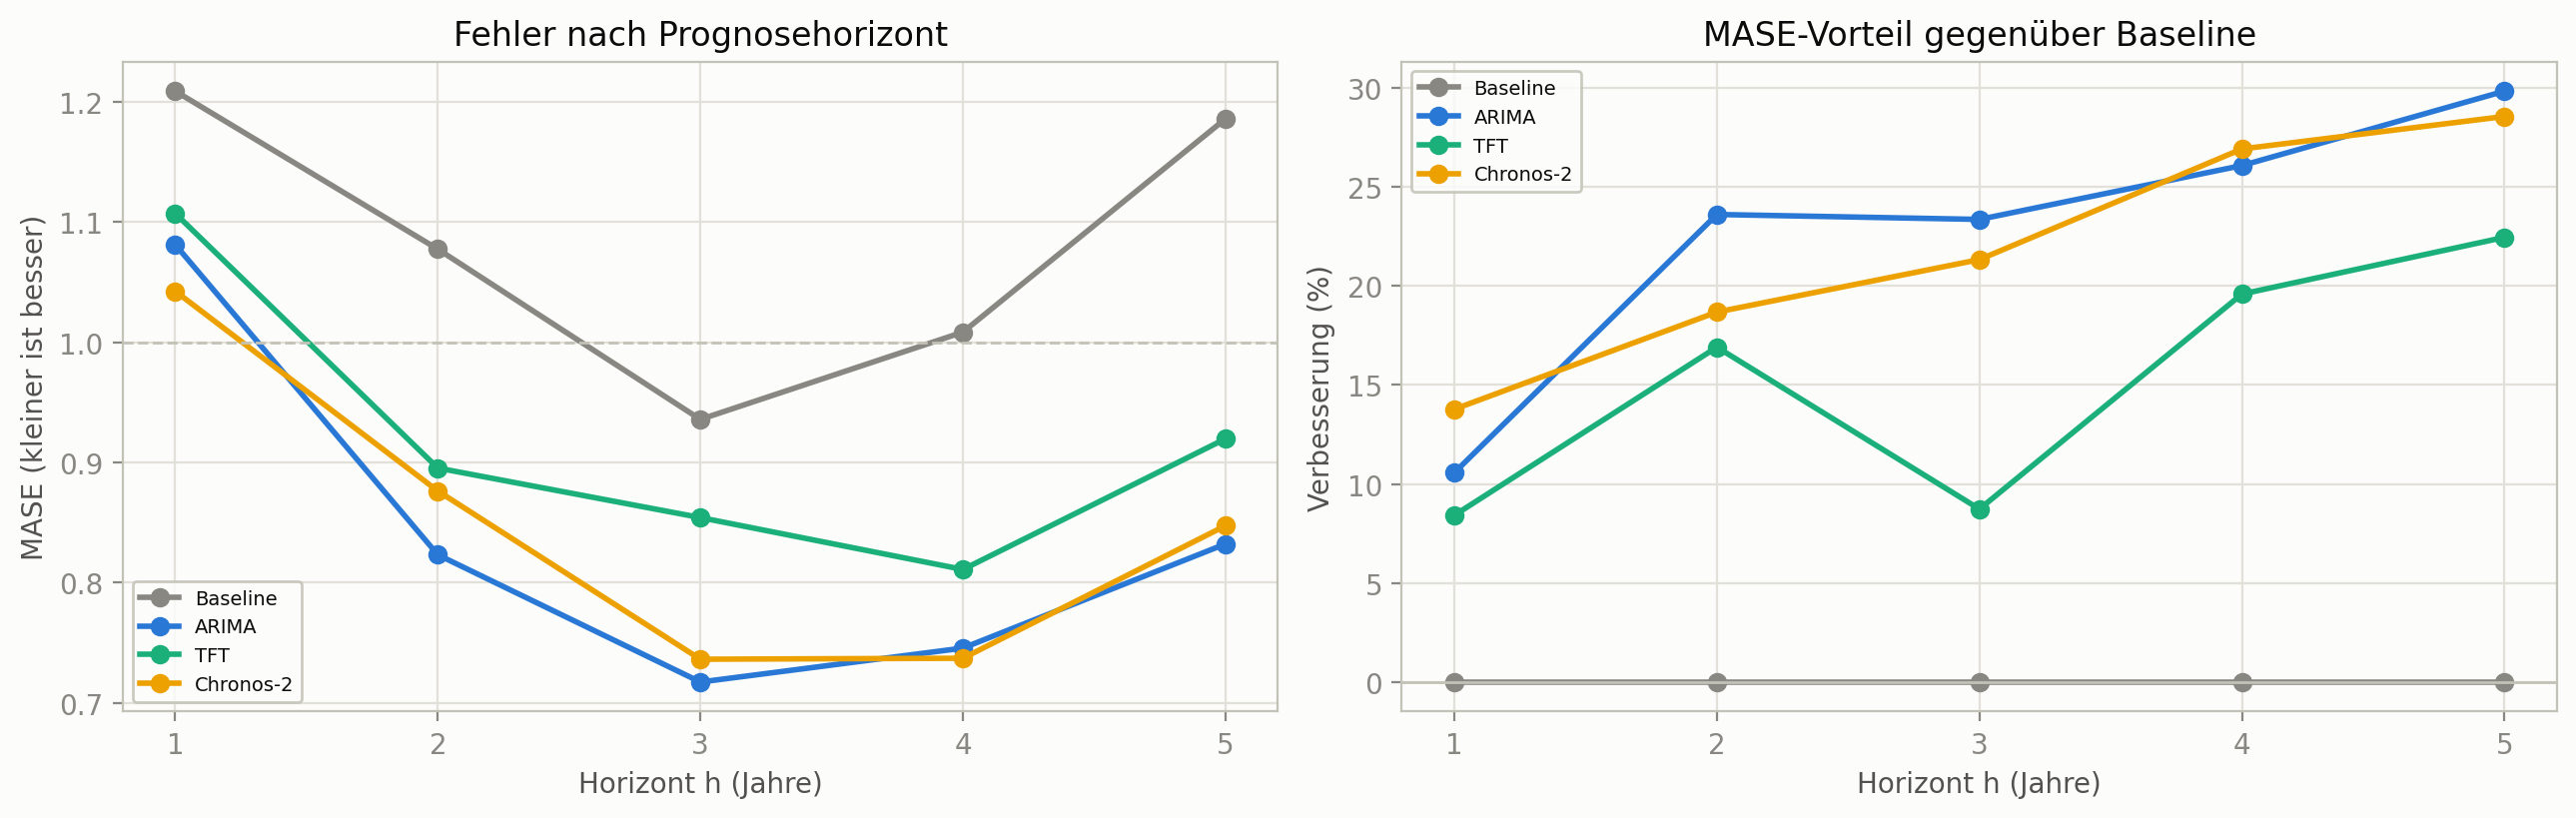

In [6]:
horizon_summary = (
    preds.groupby(["model", "h"]).apply(
        lambda group: pd.Series({
            "RMSE": evaluation.rmse(group["y_true"], group["y_pred"]),
            "MAE": evaluation.mae(group["y_true"], group["y_pred"]),
        }),
        include_groups=False,
    ).reset_index()
 )
horizon_mase = (
    scaled_errors.groupby(["model", "h"])["scaled_absolute_error"]
    .mean().rename("MASE").reset_index()
 )
horizon_summary = horizon_summary.merge(horizon_mase, on=["model", "h"])
horizon_summary = horizon_summary.merge(
    horizon_summary[horizon_summary["model"] == "rw_drift"][["h", "MASE"]],
    on="h", suffixes=("", "_baseline"),
 )
horizon_summary["MASE_vs_Baseline"] = 1 - horizon_summary["MASE"] / horizon_summary["MASE_baseline"]
display(
    with_model_label(horizon_summary)[["Modell", "h", "MASE", "RMSE", "MAE", "MASE_vs_Baseline"]]
    .rename(columns={"MASE_vs_Baseline": "MASE vs. Baseline"})
    .round(3)
 )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for model in model_order:
    data = horizon_summary[horizon_summary["model"] == model]
    axes[0].plot(data["h"], data["MASE"], marker="o", color=MODEL_COLORS[model],
                 label=MODEL_LABELS[model])
    axes[1].plot(data["h"], data["MASE_vs_Baseline"] * 100, marker="o",
                 color=MODEL_COLORS[model], label=MODEL_LABELS[model])
axes[0].axhline(1, color=plotting.BASELINE, linewidth=1, linestyle="--")
axes[0].set(title="Fehler nach Prognosehorizont", xlabel="Horizont h (Jahre)", ylabel="MASE (kleiner ist besser)")
axes[1].axhline(0, color=plotting.BASELINE, linewidth=1)
axes[1].set(title="MASE-Vorteil gegenüber Baseline", xlabel="Horizont h (Jahre)", ylabel="Verbesserung (%)")
for ax in axes:
    ax.set_xticks(range(1, config.HORIZON + 1))
    plotting.add_legend(ax, fontsize=7, loc="best")
fig.tight_layout()
plt.show()

Die höheren Fehler bei den frühen Prognosehorizonten können damit zusammenhängen, dass in den betrachteten Testzeiträumen außergewöhnliche makroökonomische Schocks wie die globale Finanzkrise und die COVID-19-Pandemie liegen. Diese Ereignisse lagen am Anfang der Horizonte und könnten so die Ergebnisse verzerren.

Abgesehen davon ist es plausibel, dass die MASE Werte steigen gegen Ende der Horizonte.

### 4.2 Stabilität über Backtest-Folds

Jeder Origin erzeugt ein separates Fünfjahres-Testfenster. Die Auswertung nach Origin zeigt, ob ein Modell konsistent arbeitet oder ob seine Gesamtgüte von einzelnen historischen Phasen abhängt. Besonders relevant ist der finale Holdout: Training bis 2019, Test 2020 bis 2024 mit dem pandemiebedingten Einbruch.

Die MASE wird auch hier erst auf Ebene eines Landes und Origins gebildet und dann gemittelt.

,Modell,origin_year,MASE,RMSE,MAE
0,ARIMA,1999,0.747,5.147,3.155
1,ARIMA,2004,0.846,4.271,3.052
2,ARIMA,2009,0.808,6.081,3.055
3,ARIMA,2014,0.558,3.360,2.147
4,ARIMA,2019,1.241,7.024,4.118
5,Chronos-2,1999,0.779,5.186,3.123
6,Chronos-2,2004,0.844,4.614,3.033
7,Chronos-2,2009,0.805,6.060,3.041
8,Chronos-2,2014,0.576,3.677,2.158
9,Chronos-2,2019,1.235,7.066,4.092


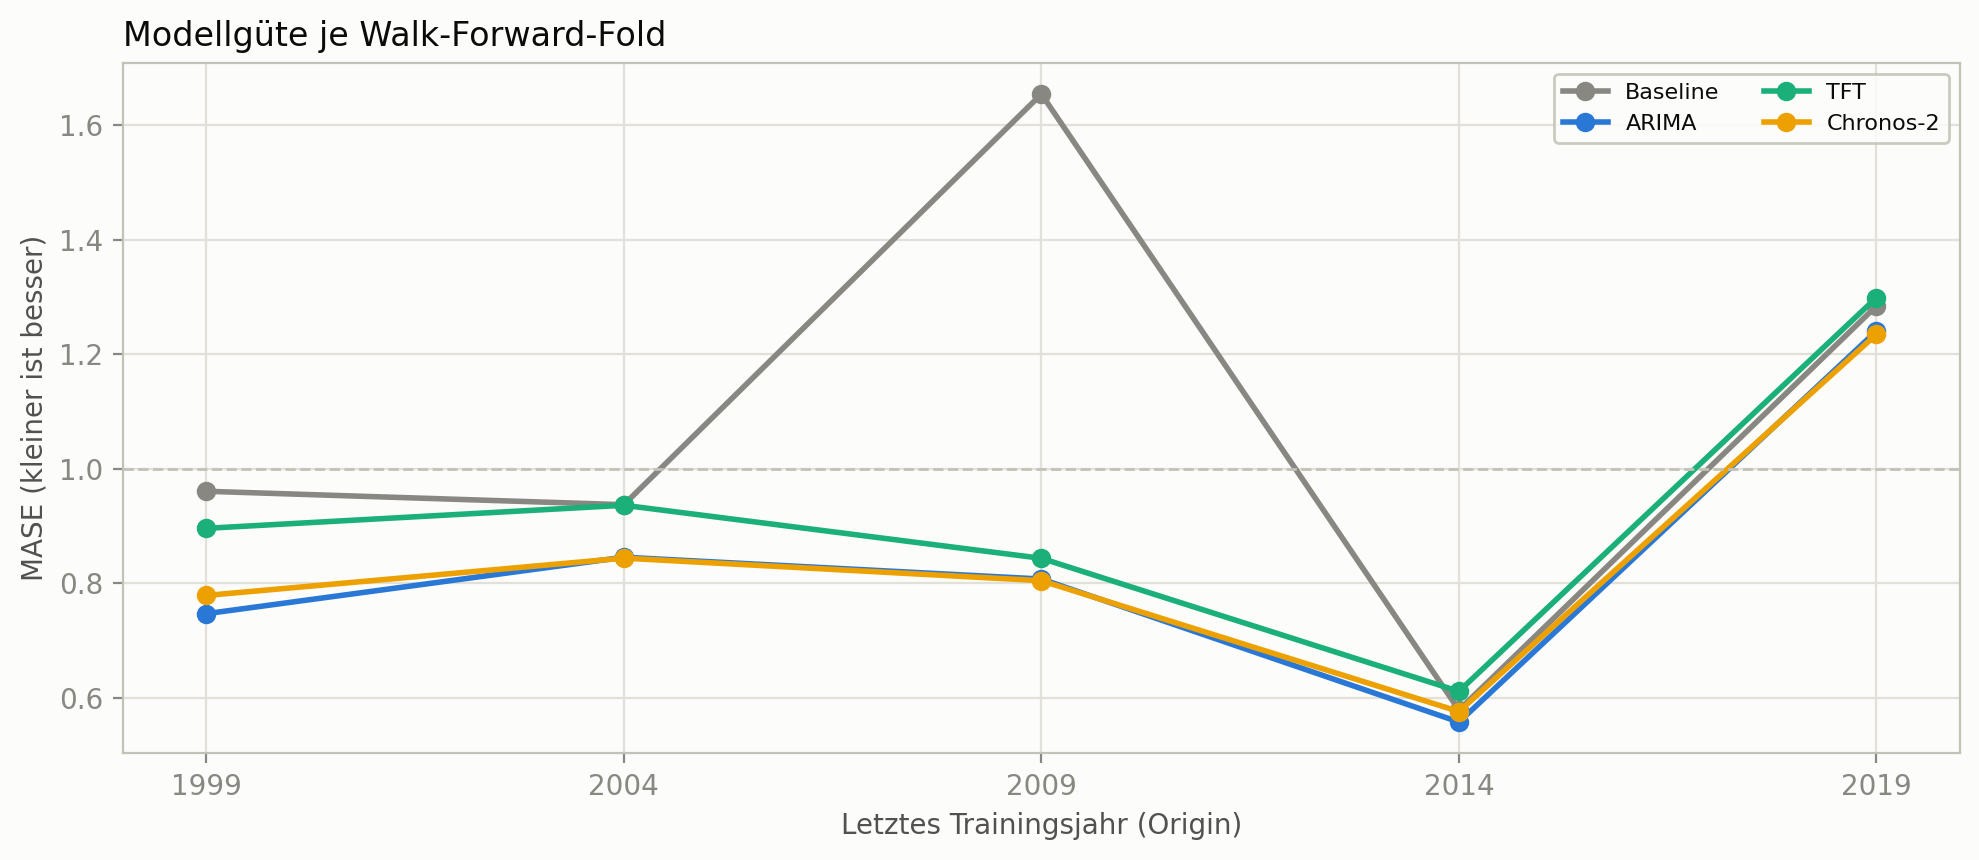

In [7]:
origin_mase = (
    mase_by_country_origin.groupby(["model", "origin_year"])["MASE"]
    .mean().reset_index()
 )
origin_errors = (
    preds.groupby(["model", "origin_year"]).apply(
        lambda group: pd.Series({
            "RMSE": evaluation.rmse(group["y_true"], group["y_pred"]),
            "MAE": evaluation.mae(group["y_true"], group["y_pred"]),
        }),
        include_groups=False,
    ).reset_index()
 )
origin_summary = origin_mase.merge(origin_errors, on=["model", "origin_year"])
display(with_model_label(origin_summary)[["Modell", "origin_year", "MASE", "RMSE", "MAE"]].round(3))

fig, ax = plt.subplots(figsize=(10, 4.4))
for model in model_order:
    data = origin_summary[origin_summary["model"] == model]
    ax.plot(data["origin_year"], data["MASE"], marker="o", color=MODEL_COLORS[model],
            label=MODEL_LABELS[model])
ax.axhline(1, color=plotting.BASELINE, linewidth=1, linestyle="--")
ax.set_xticks(config.ALL_ORIGINS)
ax.set_xlabel("Letztes Trainingsjahr (Origin)")
ax.set_ylabel("MASE (kleiner ist besser)")
ax.set_title("Modellgüte je Walk-Forward-Fold", loc="left")
plotting.add_legend(ax, ncol=2, fontsize=8, loc="best")
fig.tight_layout()
plt.show()

Auch hier sticht der Corona Fold besonders heraus.

## 5 MASE nach Region und Einkommensgruppe

Die folgende Segmentierung zeigt, für welche Ländergruppen die Modelle besser oder schlechter arbeiten. Grundlage ist weiterhin MASE je Land und Origin, nicht ein gepoolter Fehler über alle Einzelprognosen.

Die Tabellen enthalten zusätzlich die Anzahl der Länder und Folds pro Gruppe. Gruppenunterschiede mit wenigen Ländern sollten nur vorsichtig interpretiert werden.

MASE nach Region


,Modell,region,MASE,Länder,Folds
14,Baseline,East Asia & Pacific,1.106,20,100
0,ARIMA,East Asia & Pacific,0.881,20,100
21,TFT,East Asia & Pacific,0.973,20,100
7,Chronos-2,East Asia & Pacific,0.887,20,100
15,Baseline,Europe & Central Asia,1.442,27,135
1,ARIMA,Europe & Central Asia,1.042,27,135
22,TFT,Europe & Central Asia,1.185,27,135
8,Chronos-2,Europe & Central Asia,1.084,27,135
16,Baseline,Latin America & Caribbean,1.280,20,100
2,ARIMA,Latin America & Caribbean,0.921,20,100


MASE nach Einkommensgruppe


,Modell,income_group,MASE,Länder,Folds
8,Baseline,High income,1.275,46,230
0,ARIMA,High income,0.951,46,230
12,TFT,High income,1.035,46,230
4,Chronos-2,High income,0.970,46,230
9,Baseline,Low income,0.786,11,55
1,ARIMA,Low income,0.632,11,55
13,TFT,Low income,0.719,11,55
5,Chronos-2,Low income,0.601,11,55
10,Baseline,Lower middle income,0.688,27,135
2,ARIMA,Lower middle income,0.637,27,135


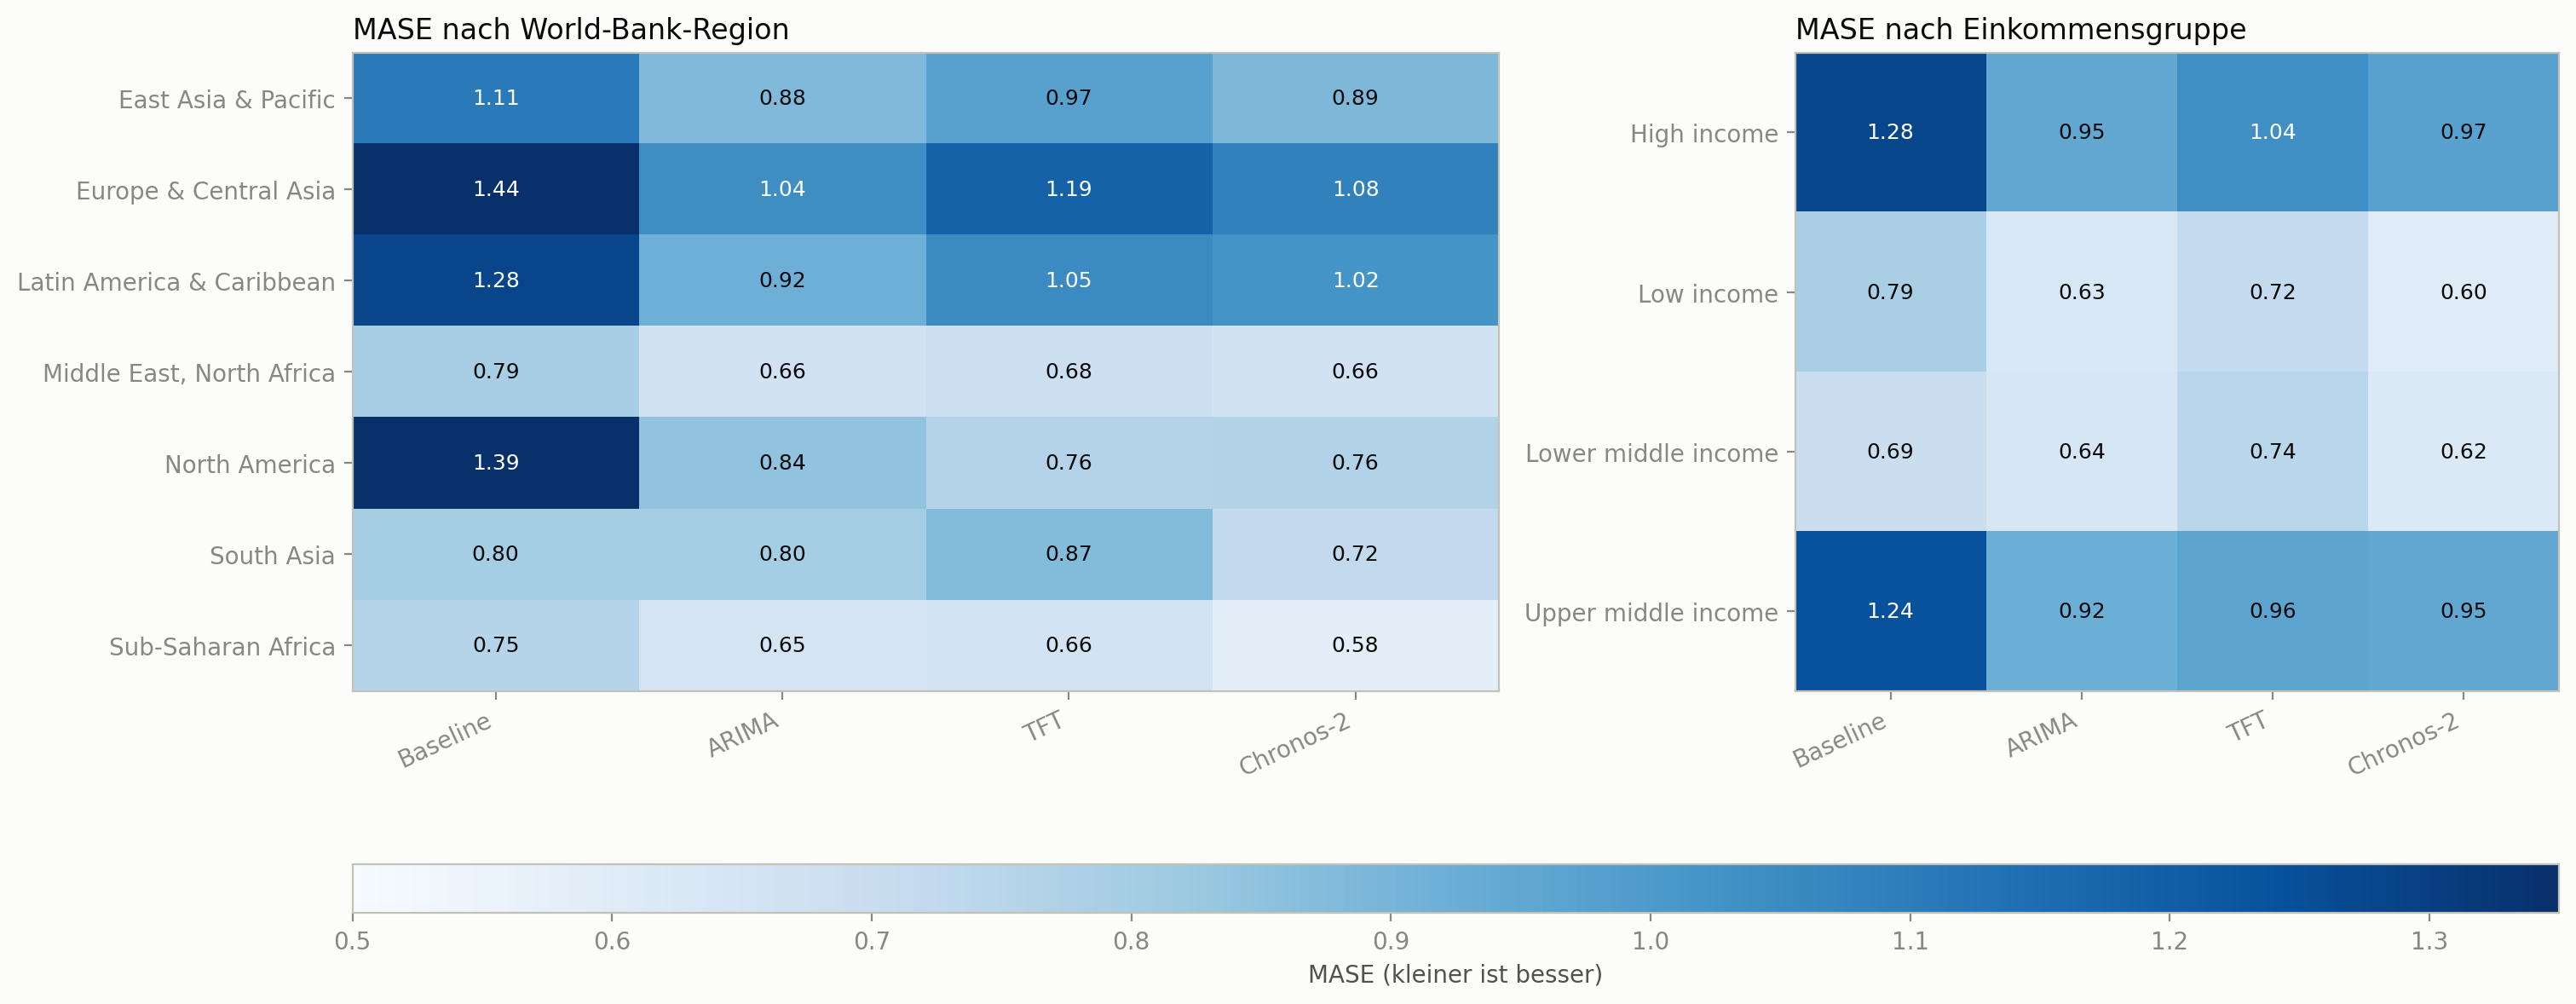

In [8]:
def summarize_mase_by_group(group_col: str) -> pd.DataFrame:
    grouped = mase_by_country_origin.merge(
        static[["country", group_col]], on="country", how="left"
    ).dropna(subset=[group_col])
    grouped[group_col] = grouped[group_col].replace(
        {"Middle East, North Africa, Afghanistan & Pakistan": "Middle East, North Africa"}
    )
    return (
        grouped.groupby(["model", group_col]).agg(
            MASE=("MASE", "mean"),
            Länder=("country", "nunique"),
            Folds=("MASE", "size"),
        ).reset_index()
    )


def plot_group_heatmap(summary: pd.DataFrame, group_col: str, title: str, ax):
    matrix = summary.pivot(index=group_col, columns="model", values="MASE")
    matrix = matrix.reindex(columns=model_order)
    image = ax.imshow(matrix.to_numpy(), aspect="auto", cmap="Blues", vmin=0.5, vmax=1.35)
    ax.set_xticks(range(len(model_order)), [MODEL_LABELS[model] for model in model_order], rotation=25, ha="right")
    ax.set_yticks(range(len(matrix.index)), matrix.index)
    ax.set_title(title, loc="left")
    ax.grid(False)
    for row_index, group in enumerate(matrix.index):
        for column_index, model in enumerate(model_order):
            value = matrix.loc[group, model]
            if pd.notna(value):
                text_color = "white" if value > 1.0 else plotting.INK
                ax.text(column_index, row_index, f"{value:.2f}", ha="center", va="center",
                        color=text_color, fontsize=9)
    return image

region_summary = summarize_mase_by_group("region")
income_summary = summarize_mase_by_group("income_group")

print("MASE nach Region")
display(with_model_label(region_summary)[["Modell", "region", "MASE", "Länder", "Folds"]].sort_values(["region", "Modell"]).round(3))
print("MASE nach Einkommensgruppe")
display(with_model_label(income_summary)[["Modell", "income_group", "MASE", "Länder", "Folds"]].sort_values(["income_group", "Modell"]).round(3))

fig, axes = plt.subplots(
    1, 2, figsize=(15, 5.8), gridspec_kw={"width_ratios": [1.5, 1]}, layout="constrained"
 )
image = plot_group_heatmap(region_summary, "region", "MASE nach World-Bank-Region", axes[0])
plot_group_heatmap(income_summary, "income_group", "MASE nach Einkommensgruppe", axes[1])
fig.colorbar(
    image,
    ax=axes,
    orientation="horizontal",
    fraction=0.08,
    pad=0.12,
    aspect=45,
    label="MASE (kleiner ist besser)",
)
plt.show()

Auffällig ist, dass die Modelle in einigen Regionen und Einkommensgruppen niedrigere MASE-Werte erreichen als in anderen. Dies deutet darauf hin, dass die BIP-Wachstumsraten dieser Ländergruppen im vorliegenden Backtest leichter prognostizierbar waren. Die beobachteten Unterschiede erlauben jedoch keine allgemeine Aussage über die wirtschaftliche Stabilität oder Krisenanfälligkeit einzelner Regionen.

Mögliche Erklärungen sind Unterschiede in der Volatilität der Wachstumsraten, der Datenqualität, der Länderzusammensetzung und der zeitlichen Lage außergewöhnlicher Ereignisse wie Finanzkrise oder COVID-19-Pandemie. Welche Faktoren die Gruppenunterschiede tatsächlich verursachen, müsste in einer gesonderten Analyse untersucht werden.

## 6 Residualdiagnostik

Residuals sind als $e_t = y_t - y_{pred,t}$ definiert. Positive Werte bedeuten, dass das Modell zu niedrig prognostiziert hat; negative Werte stehen für eine zu hohe Prognose.

Zuerst vergleichen wir Fehlerverteilung und mittleren Bias aller Modelle. Danach folgt eine detaillierte Out-of-sample-Diagnostik für ein auswählbares Modell mit Zeitverlauf, Residuen gegen Fitted Values, Histogramm, Q-Q-Plot und Fehlerkorrelation innerhalb des Forecast-Horizonts.

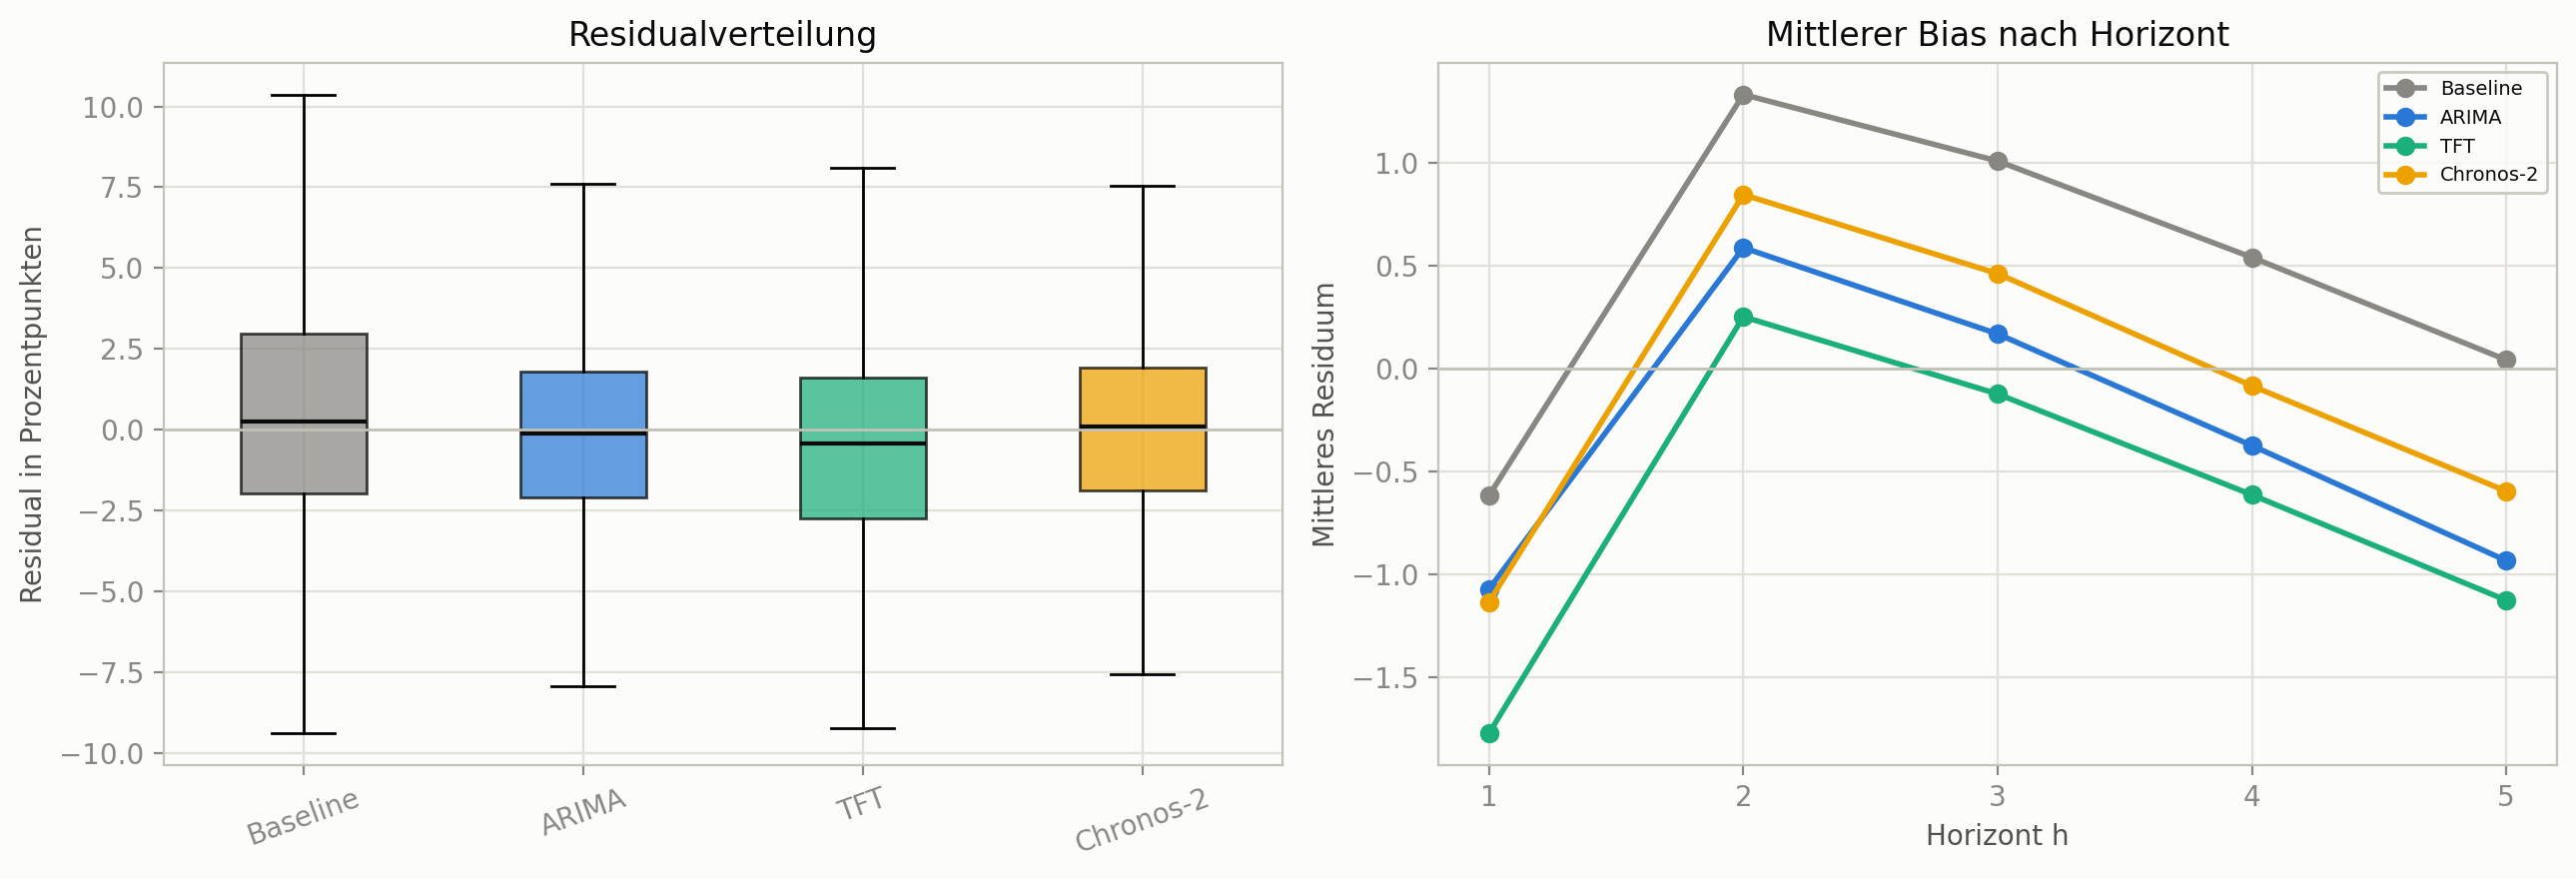

In [9]:
residuals = preds.copy()
residuals["residual"] = residuals["y_true"] - residuals["y_pred"]
bias_by_horizon = residuals.groupby(["model", "h"])["residual"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
box_data = [residuals.loc[residuals["model"] == model, "residual"] for model in model_order]
boxes = axes[0].boxplot(
    box_data, tick_labels=[MODEL_LABELS[model] for model in model_order], patch_artist=True,
    showfliers=False, medianprops={"color": plotting.INK, "linewidth": 1.5},
 )
for box, model in zip(boxes["boxes"], model_order):
    box.set(facecolor=MODEL_COLORS[model], alpha=0.72)
axes[0].axhline(0, color=plotting.BASELINE, linewidth=1)
axes[0].set(title="Residualverteilung", ylabel="Residual in Prozentpunkten")
axes[0].tick_params(axis="x", rotation=20)

for model in model_order:
    data = bias_by_horizon[bias_by_horizon["model"] == model]
    axes[1].plot(data["h"], data["residual"], marker="o", color=MODEL_COLORS[model],
                 label=MODEL_LABELS[model])
axes[1].axhline(0, color=plotting.BASELINE, linewidth=1)
axes[1].set(title="Mittlerer Bias nach Horizont", xlabel="Horizont h", ylabel="Mittleres Residuum")
axes[1].set_xticks(range(1, config.HORIZON + 1))
plotting.add_legend(axes[1], fontsize=7, loc="best")
fig.tight_layout()
plt.show()

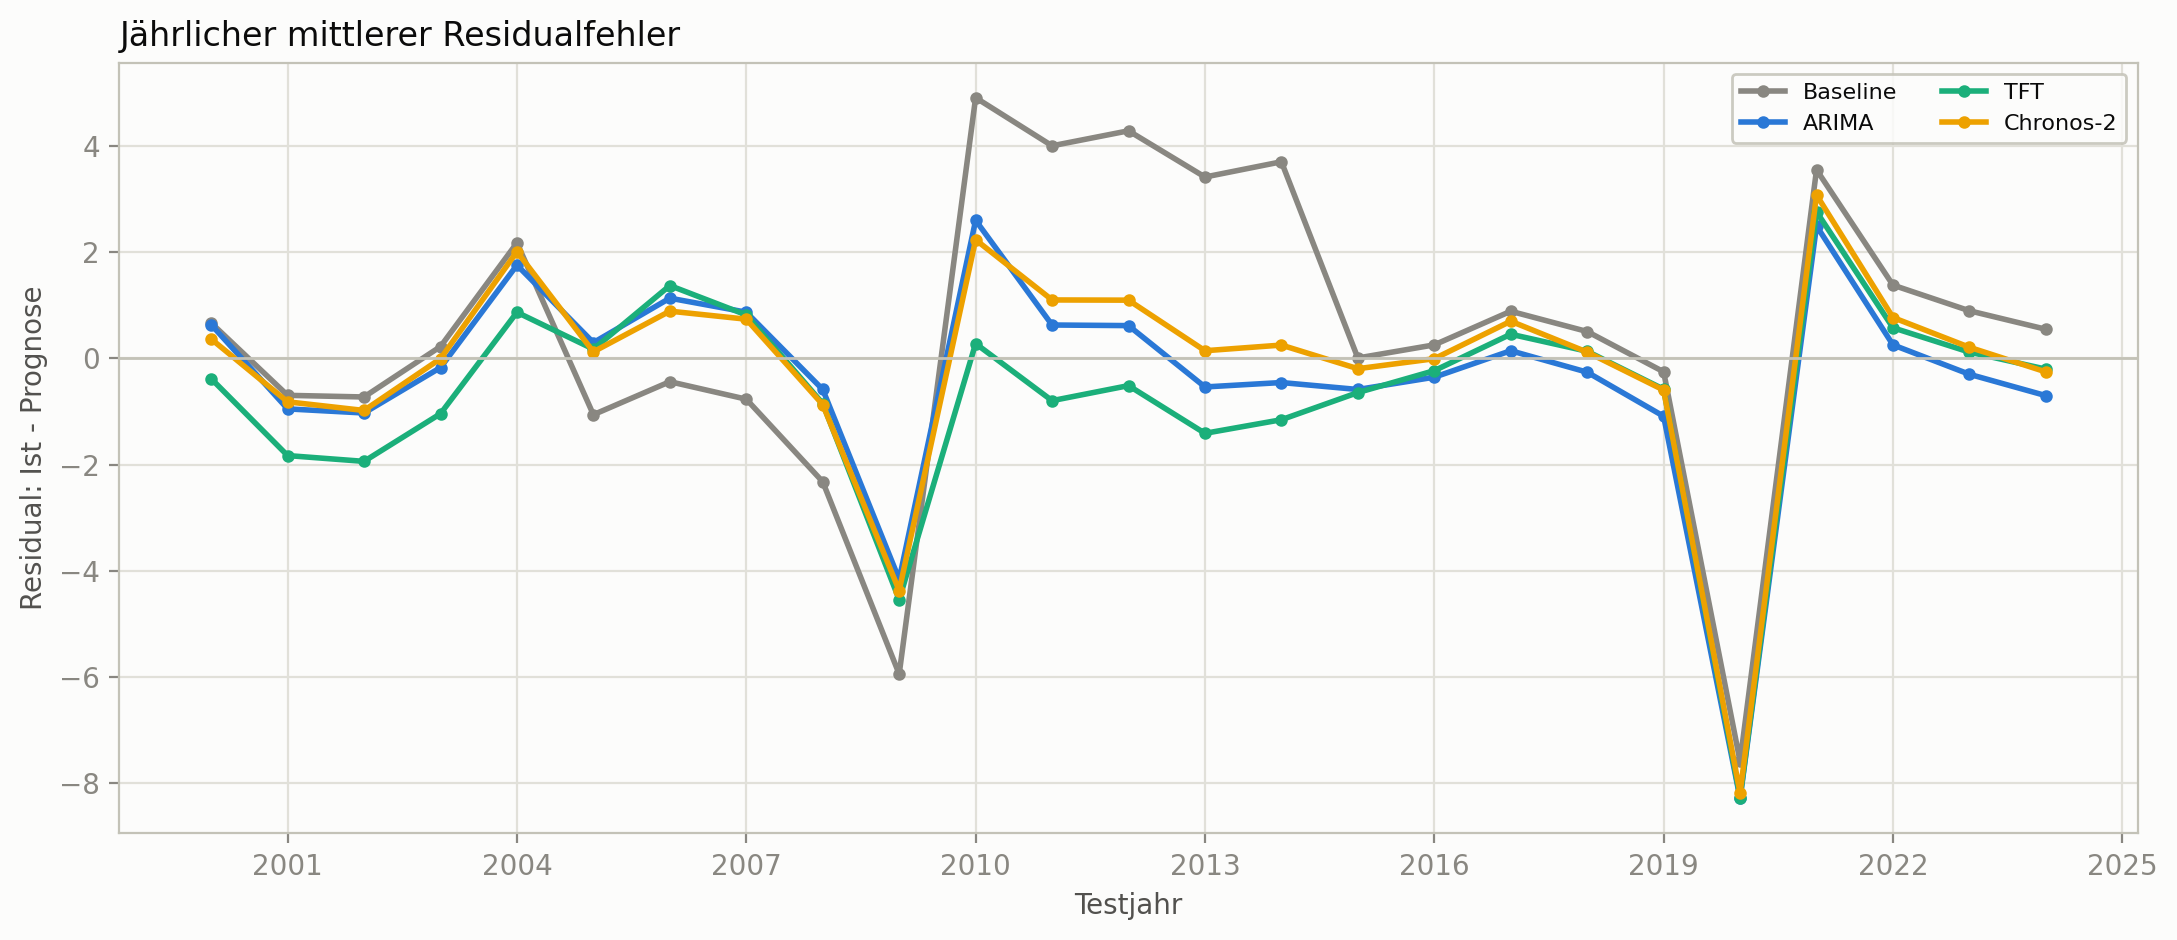

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.8))
for model in model_order:
    model_residuals = preds[preds["model"] == model].copy()
    model_residuals["residual"] = model_residuals["y_true"] - model_residuals["y_pred"]
    yearly = model_residuals.groupby("year")["residual"]
    mean = yearly.mean()
    color = MODEL_COLORS[model]
    ax.plot(mean.index, mean.values, color=color, linewidth=2, marker="o",
            markersize=3.5, label=MODEL_LABELS[model])
ax.axhline(0, color=plotting.BASELINE, linewidth=1)
ax.set_xlabel("Testjahr")
ax.set_ylabel("Residual: Ist - Prognose")
ax.set_title("Jährlicher mittlerer Residualfehler", loc="left")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plotting.add_legend(ax, ncol=2, fontsize=8, loc="best")
fig.tight_layout()
plt.show()

Insbesondere die Finanzkrise als auch die Coronapandemie sind gut erkennbar.

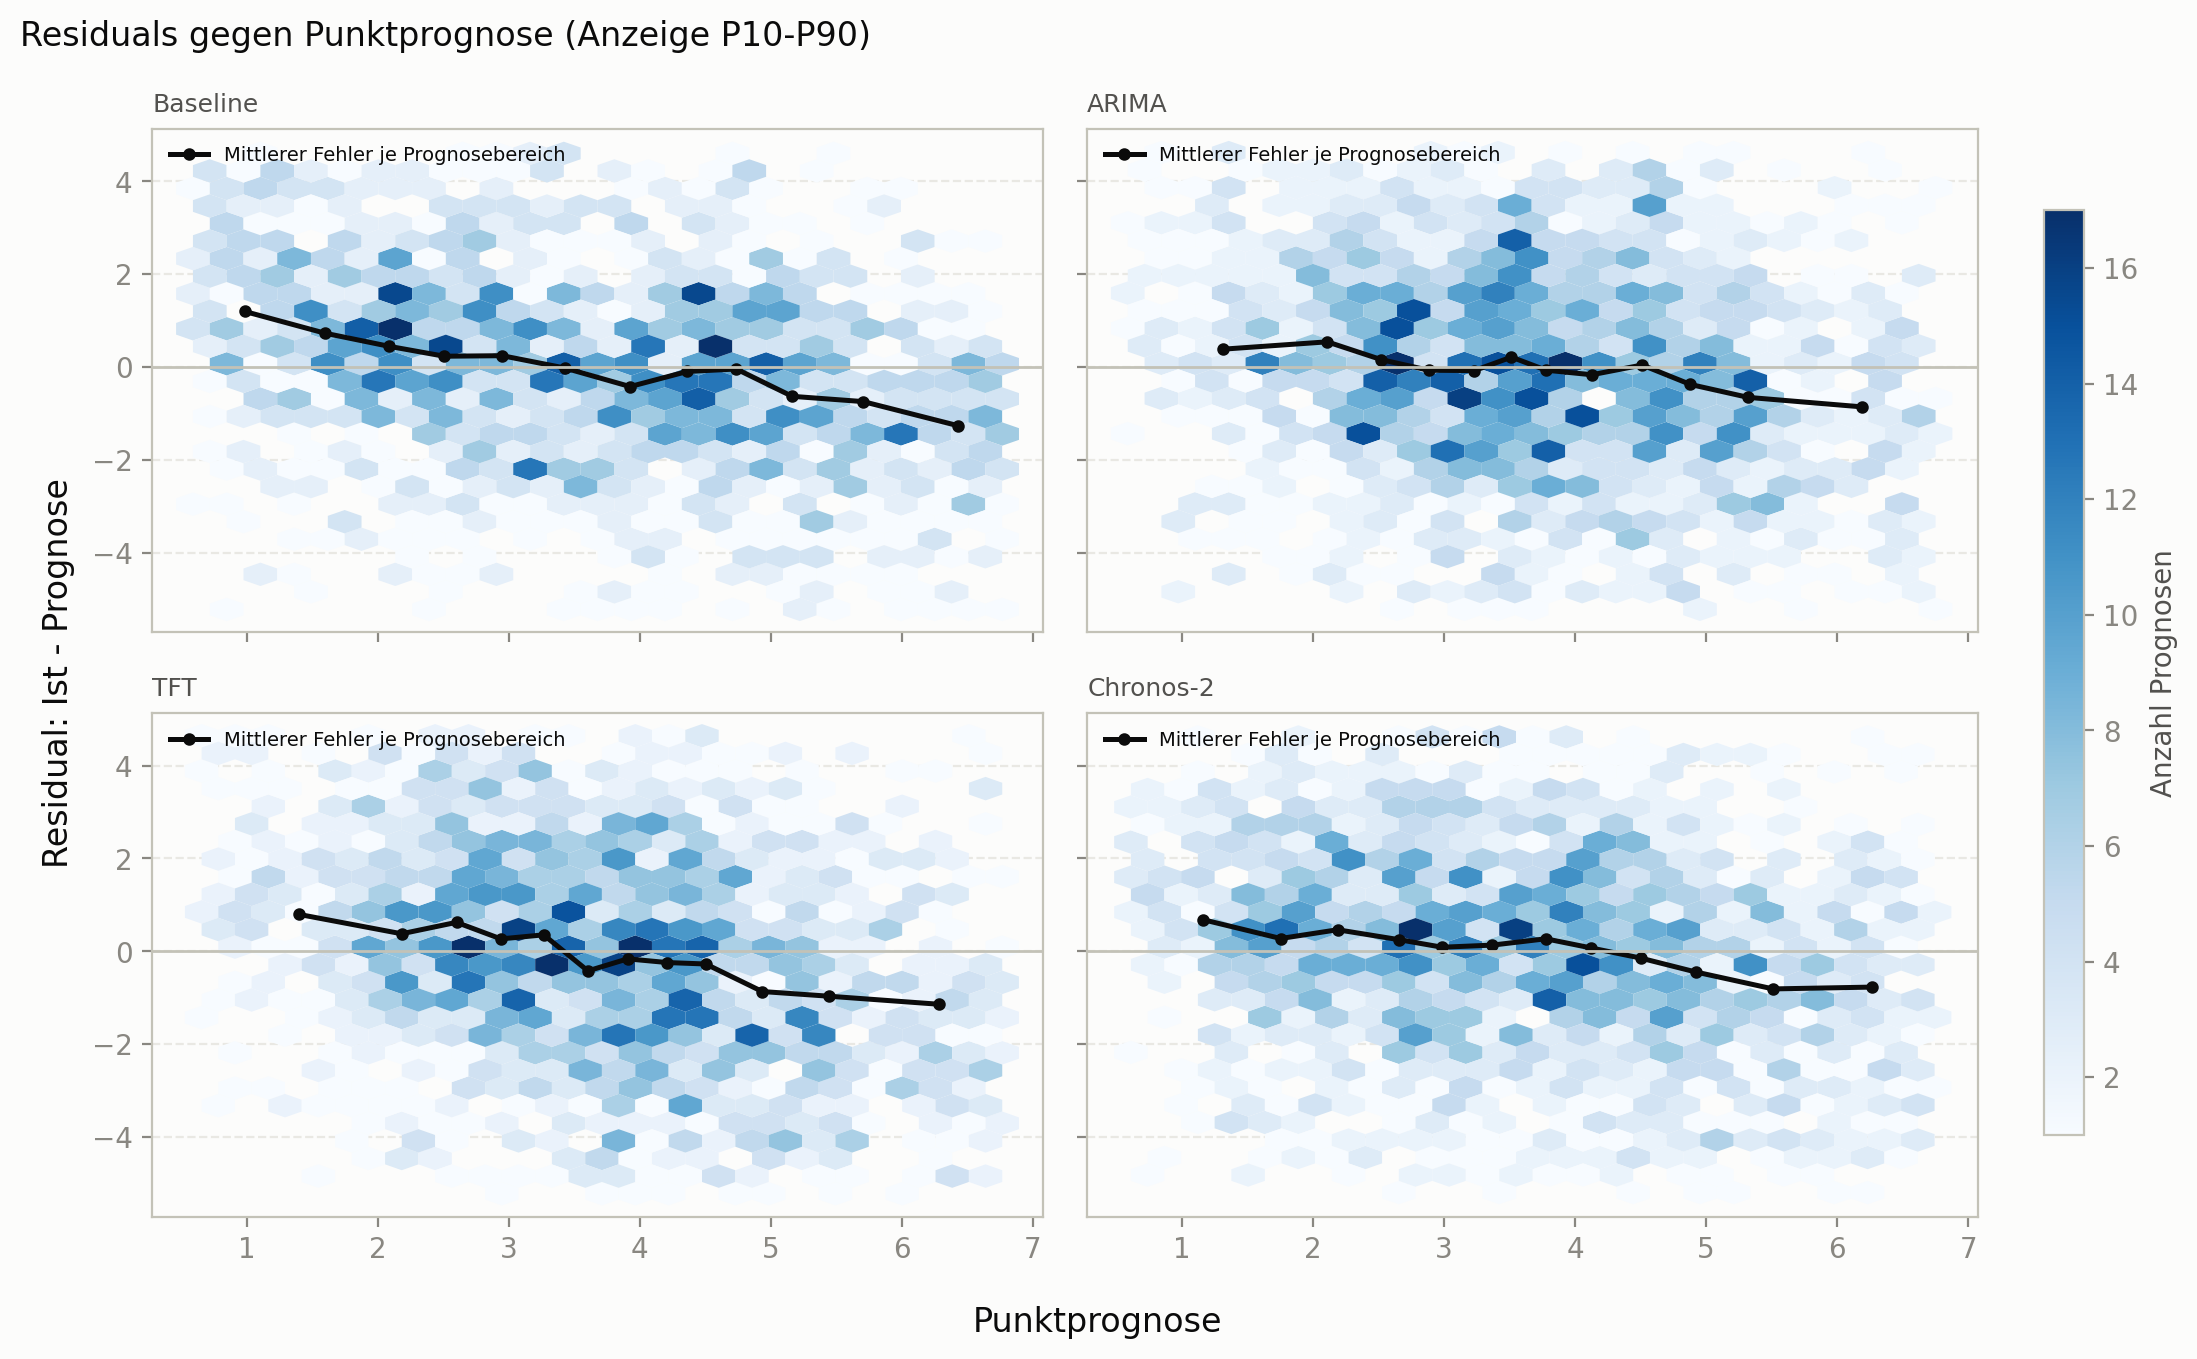

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.8), sharex=True, sharey=True)
plot_values = preds[["y_pred", "y_true"]].copy()
plot_values["residual"] = plot_values["y_true"] - plot_values["y_pred"]
pred_low, pred_high = plot_values["y_pred"].quantile([0.10, 0.90]).astype(float)
residual_low, residual_high = plot_values["residual"].quantile([0.10, 0.90]).astype(float)
for ax, model in zip(axes.ravel(), model_order):
    model_residuals = preds[preds["model"] == model].copy()
    model_residuals["residual"] = model_residuals["y_true"] - model_residuals["y_pred"]
    displayed = model_residuals.loc[
        model_residuals["y_pred"].between(pred_low, pred_high)
        & model_residuals["residual"].between(residual_low, residual_high)
    ]
    hexbin = ax.hexbin(displayed["y_pred"], displayed["residual"],
                       gridsize=24, mincnt=1, cmap="Blues", linewidths=0)
    fitted_bins = pd.qcut(displayed["y_pred"], q=12, duplicates="drop")
    trend = displayed.groupby(fitted_bins, observed=True).agg(
        y_pred=("y_pred", "mean"), residual=("residual", "mean"))
    ax.plot(trend["y_pred"], trend["residual"], color=plotting.INK,
            linewidth=1.8, marker="o", markersize=3.5,
            label="Mittlerer Fehler je Prognosebereich")
    ax.axhline(0, color=plotting.BASELINE, linewidth=1)
    ax.set_title(MODEL_LABELS[model], loc="left", fontsize=9,
                 color=plotting.INK_SECONDARY)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.grid(False, axis="x")
    for side in ("top", "right"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(plotting.BASELINE)
    ax.legend(frameon=False, fontsize=7, loc="upper left")
colorbar_ax = fig.add_axes([0.93, 0.16, 0.018, 0.68])
fig.colorbar(hexbin, cax=colorbar_ax, label="Anzahl Prognosen")
fig.supxlabel("Punktprognose")
fig.supylabel("Residual: Ist - Prognose")
fig.suptitle("Residuals gegen Punktprognose (Anzeige P10-P90)", x=0.01, ha="left")
fig.subplots_adjust(left=0.07, right=0.90, bottom=0.10, top=0.90,
                    wspace=0.05, hspace=0.16)
plt.show()

Die Mittleren Fehler zeigen ein klares Muster. Die Modelle scheinen die Daten nicht ideal zu modellieren. 

In [12]:
import ipywidgets as widgets
from IPython.display import clear_output

model_selector = widgets.Dropdown(
    options=[(MODEL_LABELS[model], model) for model in model_order],
    value=model_order[0],
    description="Modell:",
    layout=widgets.Layout(width="360px"),
)
plot_output = widgets.Output()

def show_horizon_residuals(model: str) -> None:
    with plot_output:
        clear_output(wait=True)
        evaluation.plot_residual_diagnostics(preds[preds["model"] == model])
        plt.show()

def on_model_change(change):
    if change["name"] == "value":
        show_horizon_residuals(change["new"])

model_selector.observe(on_model_change)
display(widgets.VBox([model_selector, plot_output]))
show_horizon_residuals(model_selector.value)

## 7 Unsicherheitsintervalle und statistische Tests

### 7.1 Kalibrierung der 80%-Prognoseintervalle

Nur TFT und Chronos-2 liefern in den gespeicherten Ergebnissen Quantile $q_{0.1}$ und $q_{0.9}$. Bei einem korrekt kalibrierten 80%-Intervall sollten ungefähr 80% der tatsächlichen Werte innerhalb des Intervalls liegen.

Die Abdeckung allein reicht nicht: Sehr breite Intervalle können eine hohe Abdeckung künstlich erkaufen. Deshalb wird zusätzlich die mittlere Intervallbreite berichtet.

,Modell,Pinball q10,Pinball q90,80%-Abdeckung,Mittlere Intervallbreite
0,Chronos-2,0.959,0.801,0.843,11.447
1,TFT,1.078,0.892,0.674,8.480


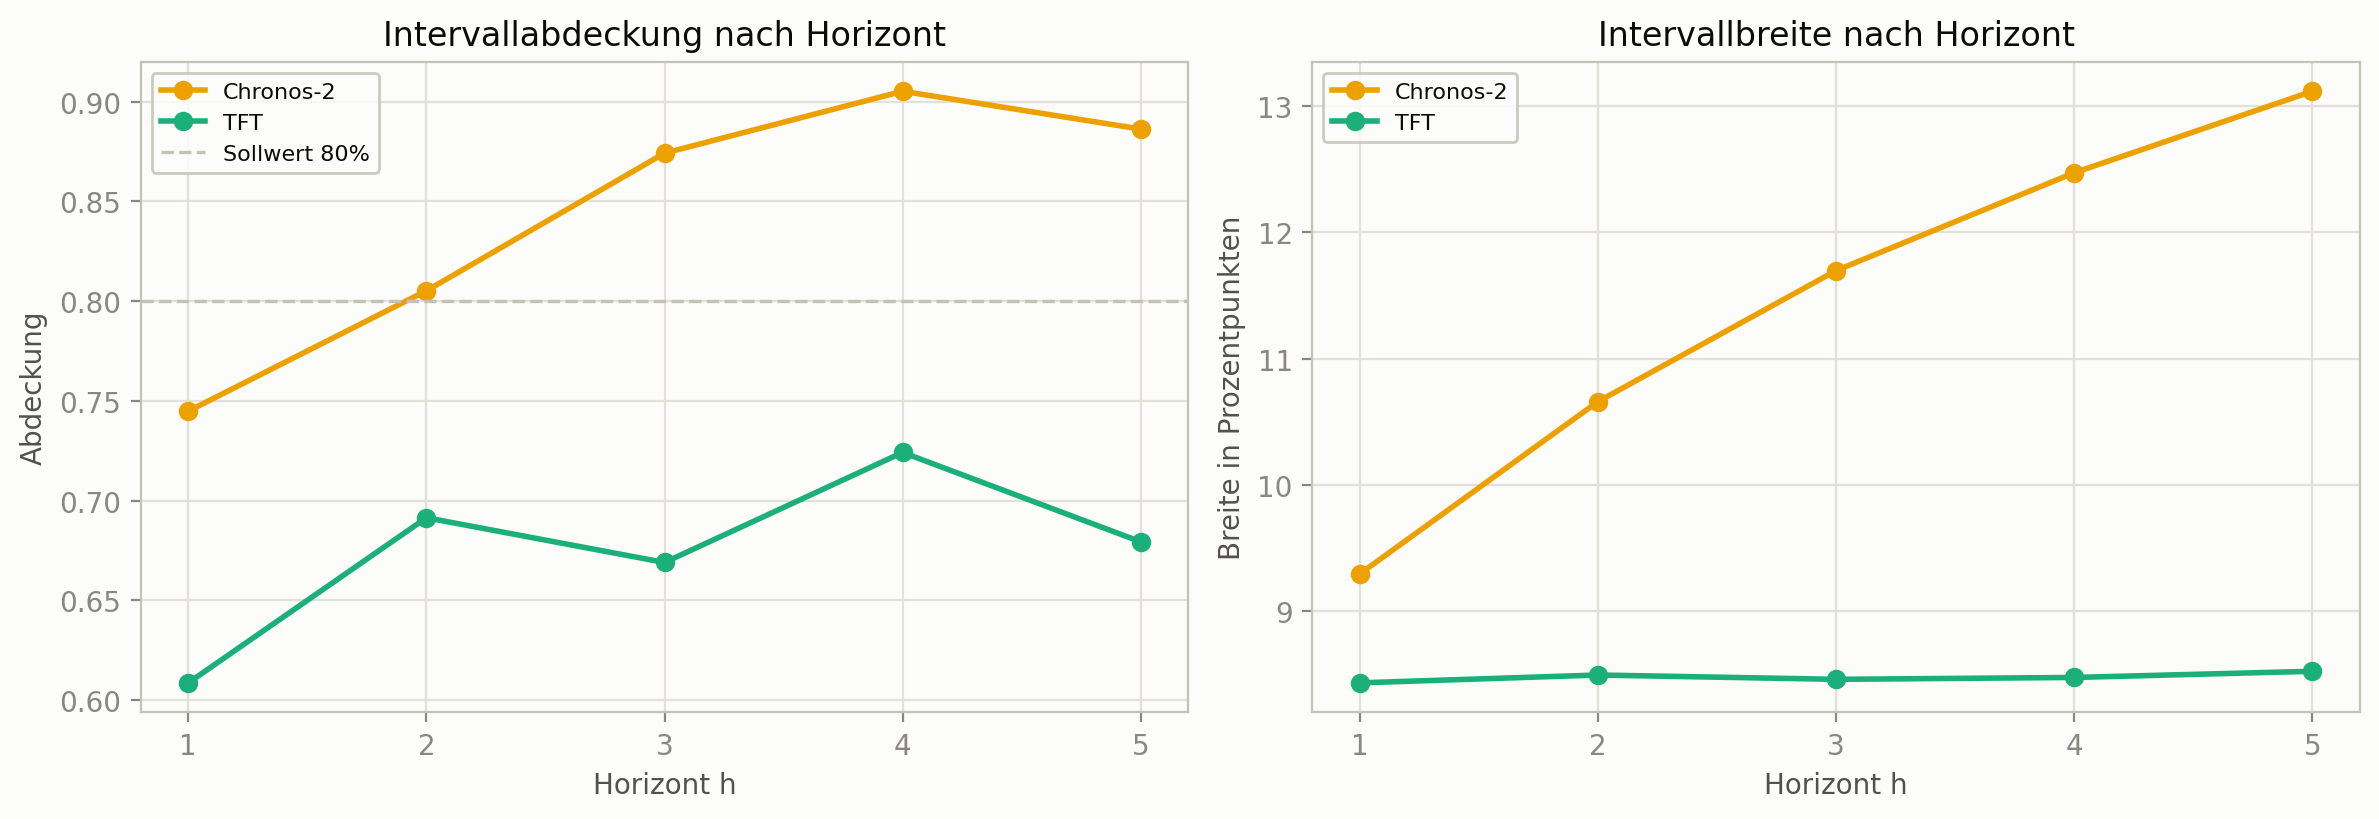

In [13]:
probabilistic = preds.dropna(subset=["q10", "q90"]).copy()
interval_summary = (
    probabilistic.groupby("model").apply(
        lambda group: pd.Series({
            "Pinball q10": evaluation.pinball_loss(group["y_true"], group["q10"], 0.1),
            "Pinball q90": evaluation.pinball_loss(group["y_true"], group["q90"], 0.9),
            "80%-Abdeckung": evaluation.interval_coverage(group["y_true"], group["q10"], group["q90"]),
            "Mittlere Intervallbreite": (group["q90"] - group["q10"]).mean(),
        }),
        include_groups=False,
    ).reset_index()
 )
interval_summary["Modell"] = interval_summary["model"].map(MODEL_LABELS)
display(interval_summary[["Modell", "Pinball q10", "Pinball q90", "80%-Abdeckung", "Mittlere Intervallbreite"]].round(3))

calibration_by_horizon = (
    probabilistic.groupby(["model", "h"]).apply(
        lambda group: pd.Series({
            "coverage": evaluation.interval_coverage(group["y_true"], group["q10"], group["q90"]),
            "width": (group["q90"] - group["q10"]).mean(),
        }),
        include_groups=False,
    ).reset_index()
 )
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for model in interval_summary["model"]:
    data = calibration_by_horizon[calibration_by_horizon["model"] == model]
    axes[0].plot(data["h"], data["coverage"], marker="o", color=MODEL_COLORS[model], label=MODEL_LABELS[model])
    axes[1].plot(data["h"], data["width"], marker="o", color=MODEL_COLORS[model], label=MODEL_LABELS[model])
axes[0].axhline(0.8, color=plotting.BASELINE, linewidth=1.2, linestyle="--", label="Sollwert 80%")
axes[0].set(title="Intervallabdeckung nach Horizont", xlabel="Horizont h", ylabel="Abdeckung")
axes[1].set(title="Intervallbreite nach Horizont", xlabel="Horizont h", ylabel="Breite in Prozentpunkten")
for ax in axes:
    ax.set_xticks(range(1, config.HORIZON + 1))
    plotting.add_legend(ax, fontsize=8, loc="best")
fig.tight_layout()
plt.show()

### 7.2 Paarweise Tests gegen die Baseline und Gewinnanteile

Die aggregierte MASE zeigt Mittelwerte, aber nicht, ob ein Modell in vielen Ländern konsistent besser ist. Deshalb vergleichen wir die MASE je identischer Kombination aus Land und Origin paarweise mit der Drift-Baseline mittels Wilcoxon-Vorzeichen-Rang-Test. Die Tests betreffen somit jeweils ARIMA, TFT und Chronos-2 gegenüber der Baseline, nicht direkte Vergleiche zwischen diesen drei Modellen.

Die Spalte `Delta MASE` ist als Baseline minus Modell definiert. Positive Werte sprechen somit für das jeweilige Modell. Die Gewinnanteile zeigen außerdem, welches Modell innerhalb eines Länder-Origin-Falls die kleinste MASE erzielt.

,Vergleich,Paare,Delta MASE,Wilcoxon p,Gepaarter t-Test p
0,ARIMA vs. Baseline,580,0.243553,0.000000,0.000000
1,TFT vs. Baseline,580,0.165933,0.000805,0.000002
2,Chronos-2 vs. Baseline,580,0.235546,0.000000,0.000000


,Modell,Gewinne,Gewinnanteil (%)
rw_drift,Baseline,127,21.9
arima,ARIMA,157,27.1
tft,TFT,148,25.5
chronos2,Chronos-2,148,25.5


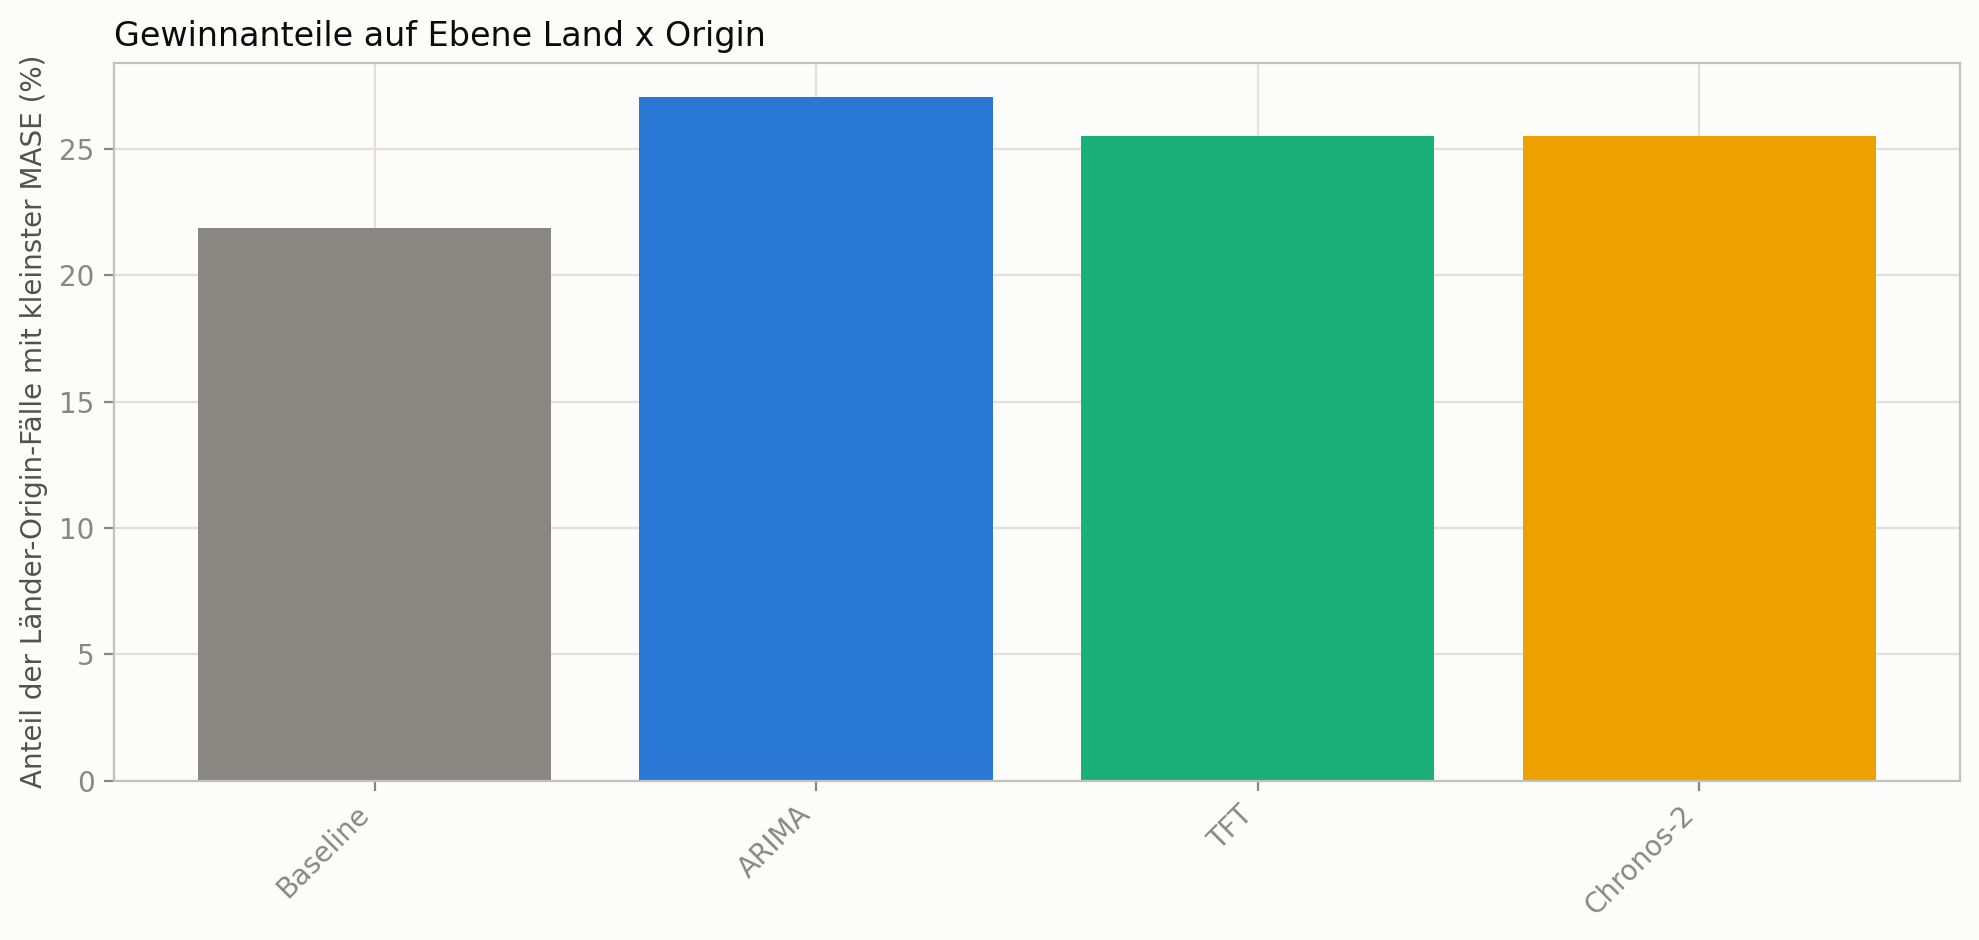

In [14]:
mase_wide = mase_by_country_origin.pivot(
    index=["country", "origin_year"], columns="model", values="MASE"
 ).reindex(columns=model_order)

comparisons = [
    ("rw_drift", "arima", "ARIMA vs. Baseline"),
    ("rw_drift", "tft", "TFT vs. Baseline"),
    ("rw_drift", "chronos2", "Chronos-2 vs. Baseline"),
]
test_rows = []
for reference, candidate, label in comparisons:
    test = evaluation.paired_forecast_test(mase_wide[reference], mase_wide[candidate])
    test_rows.append({
        "Vergleich": label,
        "Paare": test["n_pairs"],
        "Delta MASE": test["mean_diff"],
        "Wilcoxon p": test["wilcoxon_p"],
        "Gepaarter t-Test p": test["ttest_p"],
    })
paired_tests = pd.DataFrame(test_rows)
display(paired_tests.round(7))

winners = mase_wide.idxmin(axis=1).value_counts().reindex(model_order, fill_value=0)
win_rates = pd.DataFrame({
    "model": winners.index,
    "Gewinne": winners.to_numpy(),
    "Gewinnanteil (%)": winners / len(mase_wide) * 100,
})
win_rates["Modell"] = win_rates["model"].map(MODEL_LABELS)
display(win_rates[["Modell", "Gewinne", "Gewinnanteil (%)"]].round(1))

fig, ax = plt.subplots(figsize=(10, 4.8))
bar_positions = np.arange(len(win_rates))
ax.bar(
    bar_positions,
    win_rates["Gewinnanteil (%)"],
    color=[MODEL_COLORS[model] for model in win_rates["model"]],
)
ax.set_xticks(bar_positions, win_rates["Modell"], rotation=45, ha="right")
ax.set_ylabel("Anteil der Länder-Origin-Fälle mit kleinster MASE (%)")
ax.set_title("Gewinnanteile auf Ebene Land x Origin", loc="left")
fig.tight_layout()
plt.show()

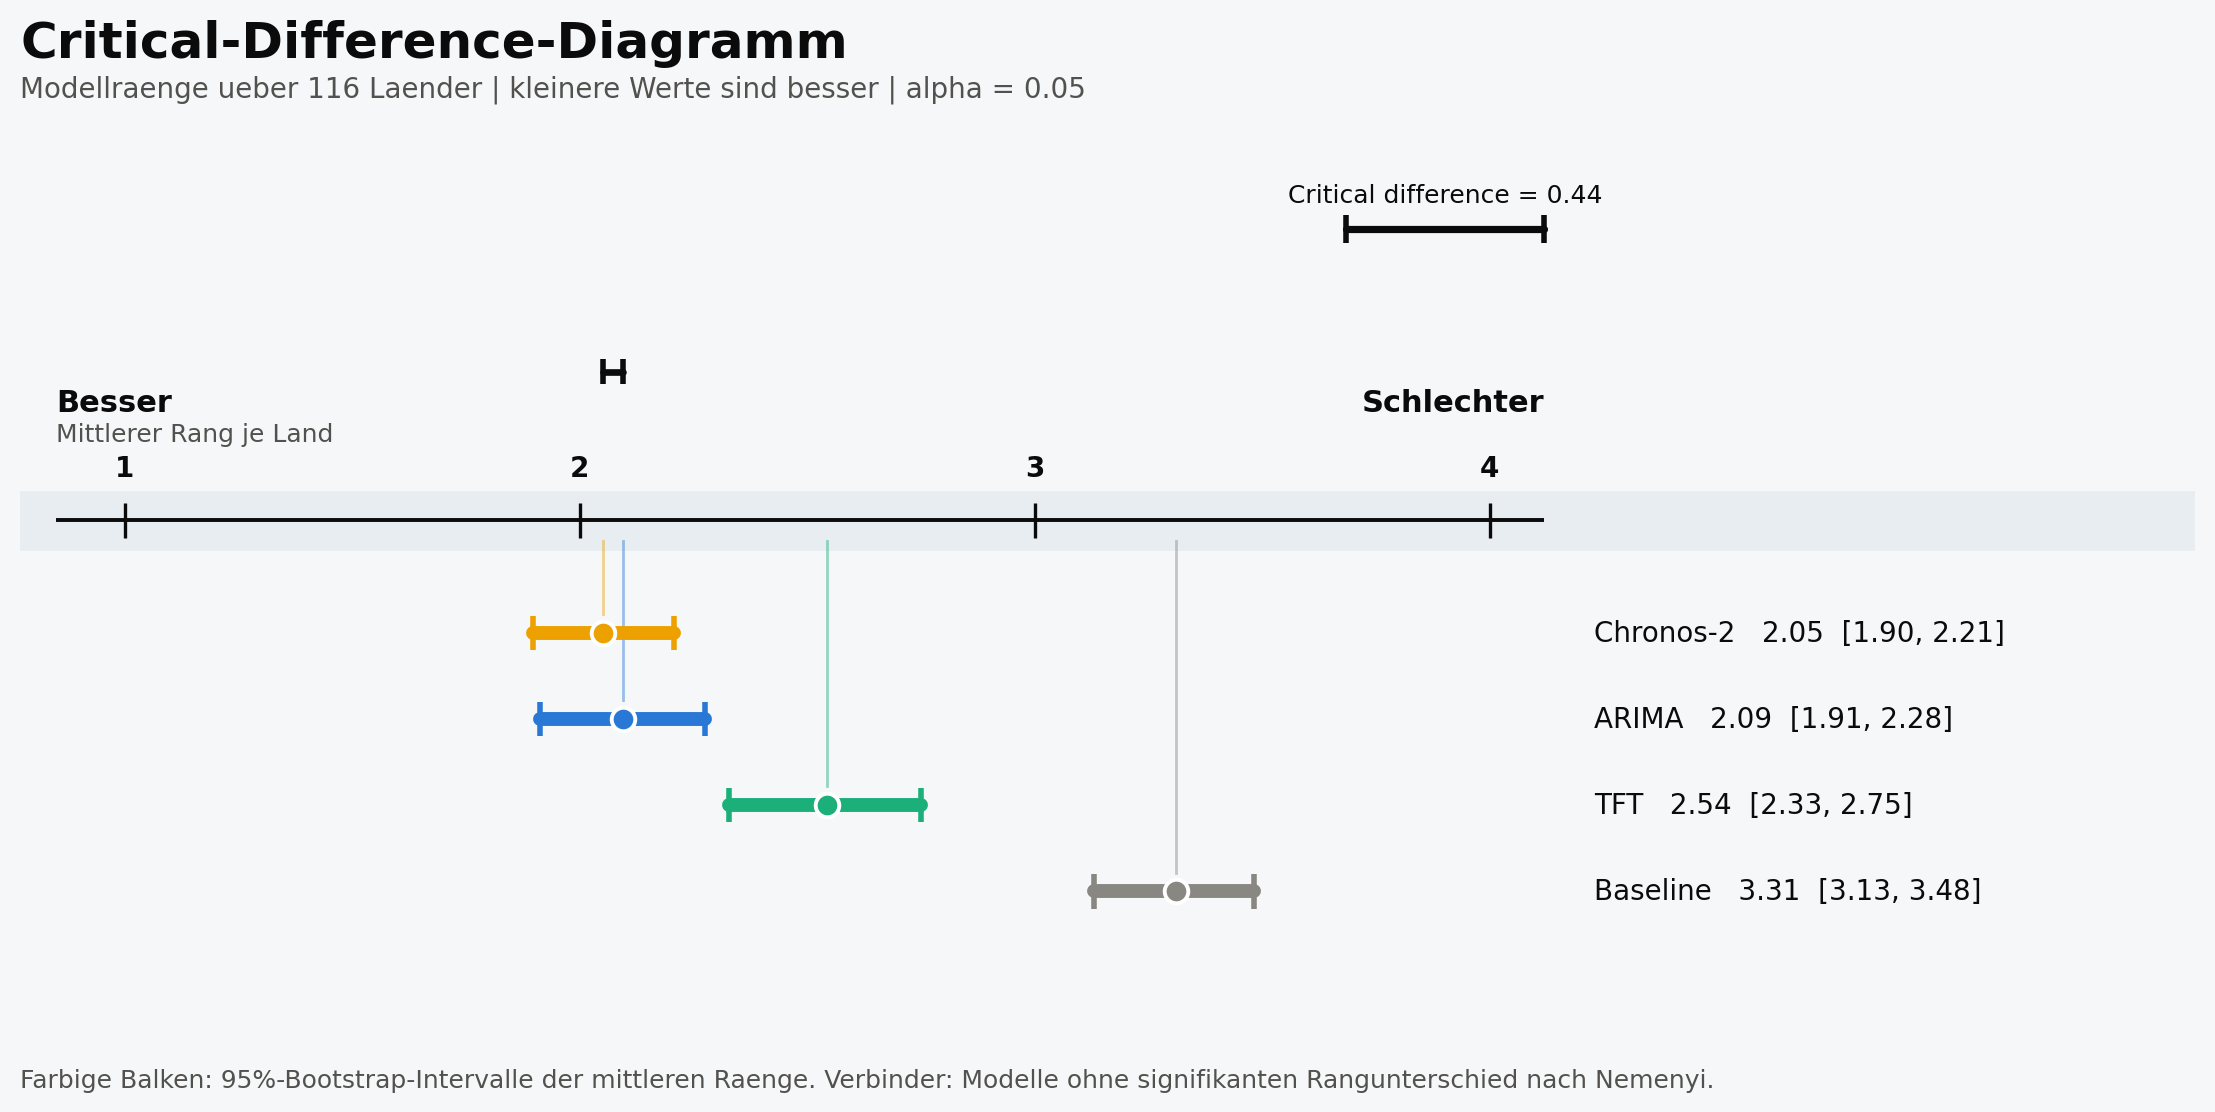

In [15]:
from scipy import stats

# Kritisches-Differenz-Diagramm auf Laenderebene.
country_mase = mase_wide.groupby(level="country").mean()
country_ranks = country_mase.rank(axis=1, method="average", ascending=True)
average_ranks = country_ranks.mean().reindex(model_order)

n_countries = len(country_ranks)
n_models = len(model_order)
alpha = 0.05
q_alpha = stats.studentized_range.ppf(1 - alpha, n_models, np.inf) / np.sqrt(2)
critical_difference = q_alpha * np.sqrt(n_models * (n_models + 1) / (6 * n_countries))

# Bootstrap-Intervalle beschreiben die Stichprobenunsicherheit der mittleren Raenge.
rng = np.random.default_rng(42)
n_bootstrap = 10_000
bootstrap_indices = rng.integers(0, n_countries, size=(n_bootstrap, n_countries))
bootstrap_ranks = country_ranks.to_numpy()[bootstrap_indices].mean(axis=1)
rank_intervals = pd.DataFrame(
    np.quantile(bootstrap_ranks, [0.025, 0.975], axis=0).T,
    index=country_ranks.columns,
    columns=["lower", "upper"],
).reindex(model_order)

ranked_models = average_ranks.sort_values()
rank_positions = ranked_models.to_numpy()

# Maximale zusammenhaengende Modellgruppen innerhalb der Nemenyi-CD.
non_significant_groups = []
for start in range(n_models - 1):
    end = start + 1
    while end + 1 < n_models and rank_positions[end + 1] - rank_positions[start] <= critical_difference:
        end += 1
    if rank_positions[end] - rank_positions[start] <= critical_difference:
        non_significant_groups.append((start, end))
non_significant_groups = [
    group for group in non_significant_groups
    if not any(
        existing[0] <= group[0] and existing[1] >= group[1]
        for existing in non_significant_groups
        if existing != group
    )
]

fig, ax = plt.subplots(figsize=(12.5, 6.2), facecolor="#f6f7f9")
fig.subplots_adjust(left=0.09, right=0.96, top=0.82, bottom=0.18)
ax.set_facecolor("#f6f7f9")

axis_min, axis_max = 1, n_models
plot_left, plot_right = 0.85, 4.12
rank_axis_y = 0.0
model_rows = np.linspace(-0.72, -2.37, n_models)

# Rank axis with a subtle reference band.
ax.axhspan(-0.18, 0.18, color="#e8edf2", zorder=0)
ax.hlines(rank_axis_y, plot_left, plot_right, color=plotting.INK, linewidth=1.4, zorder=2)
for rank in range(axis_min, axis_max + 1):
    ax.vlines(rank, -0.11, 0.11, color=plotting.INK, linewidth=1.2, zorder=2)
    ax.text(rank, 0.24, str(rank), ha="center", va="bottom", fontsize=10,
            color=plotting.INK, weight="bold")

ax.text(plot_left, 0.66, "Besser", ha="left", va="bottom", fontsize=11,
        color=plotting.INK, weight="bold")
ax.text(plot_right, 0.66, "Schlechter", ha="right", va="bottom", fontsize=11,
        color=plotting.INK, weight="bold")
ax.text(plot_left, 0.47, "Mittlerer Rang je Land", ha="left", va="bottom", fontsize=9,
        color=plotting.INK_SECONDARY)

# Model means, bootstrap intervals, and readable right-aligned labels.
for row_y, (model, rank) in zip(model_rows, ranked_models.items()):
    interval = rank_intervals.loc[model]
    color = MODEL_COLORS[model]
    ax.plot([interval["lower"], interval["upper"]], [row_y, row_y],
            color=color, linewidth=5, solid_capstyle="round", zorder=3)
    ax.vlines([interval["lower"], interval["upper"]], row_y - 0.11, row_y + 0.11,
              color=color, linewidth=2, zorder=4)
    ax.scatter(rank, row_y, s=72, color=color, edgecolor="white", linewidth=1.4, zorder=5)
    ax.plot([rank, rank], [rank_axis_y - 0.13, row_y + 0.12],
            color=color, linewidth=1.0, alpha=0.45, zorder=1)
    ax.text(
        4.23, row_y,
        f"{MODEL_LABELS[model]}   {rank:.2f}  [{interval['lower']:.2f}, {interval['upper']:.2f}]",
        ha="left", va="center", fontsize=10, color=plotting.INK,
    )

# Nemenyi non-significance connectors sit above the rank axis.
for group_index, (start, end) in enumerate(non_significant_groups):
    group_y = 0.95 + group_index * 0.28
    ax.plot([rank_positions[start], rank_positions[end]], [group_y, group_y],
            color=plotting.INK, linewidth=2.4, solid_capstyle="round", zorder=3)
    ax.vlines([rank_positions[start], rank_positions[end]], group_y - 0.08, group_y + 0.08,
              color=plotting.INK, linewidth=2.0, zorder=3)

# Critical-difference key.
cd_y = 1.86
cd_start = plot_right - critical_difference
ax.plot([cd_start, plot_right], [cd_y, cd_y], color=plotting.INK, linewidth=2.6,
        solid_capstyle="round")
ax.vlines([cd_start, plot_right], cd_y - 0.09, cd_y + 0.09,
          color=plotting.INK, linewidth=2)
ax.text((cd_start + plot_right) / 2, cd_y + 0.14,
        f"Critical difference = {critical_difference:.2f}",
        ha="center", va="bottom", fontsize=9, color=plotting.INK)

ax.set_xlim(plot_left - 0.08, 5.55)
ax.set_ylim(-2.82, 2.25)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.09, 0.94,
    "Critical-Difference-Diagramm",
    ha="left", va="top", fontsize=18, weight="bold", color=plotting.INK,
 )
fig.text(
    0.09, 0.895,
    f"Modellraenge ueber {n_countries} Laender | kleinere Werte sind besser | alpha = {alpha:.2f}",
    ha="left", va="top", fontsize=10, color=plotting.INK_SECONDARY,
 )
fig.text(
    0.09, 0.075,
    "Farbige Balken: 95%-Bootstrap-Intervalle der mittleren Raenge. "
    "Verbinder: Modelle ohne signifikanten Rangunterschied nach Nemenyi.",
    ha="left", va="bottom", fontsize=9, color=plotting.INK_SECONDARY,
 )
plt.show()

## 8 Fazit

### 8.1 Das beste Model ist ...

Im vorliegenden Walk-Forward-Backtest erzielt **ARIMA** die niedrigste globale MASE (0,840); **Chronos-2** liegt mit 0,848 nahezu gleichauf. Beide Modelle verbessern die MASE gegenüber der Drift-Baseline deutlich, während ARIMA außerdem in den meisten Länder-Origin-Fällen die kleinste MASE erreicht. Die Rangbetrachtung auf Länderebene ergänzt dieses Bild: Chronos-2 hat den besten mittleren Rang, gefolgt von ARIMA. Kleine Unterschiede zwischen diesen beiden Modellen sollten daher nicht überinterpretiert werden.

Über die Horizonte bleibt der Vorteil gegenüber der Baseline für alle drei Modelle erhalten. Für probabilistische Prognosen ist Chronos-2 der stärkere Kandidat: Seine 80%-Intervalle erreichen insgesamt eine Abdeckung von 84,3% und liegen damit näher am Sollwert als TFT (67,4%). Diesen Vorteil erkauft Chronos-2 mit breiteren Intervallen. Für reine Punktprognosen ist ARIMA die naheliegende Standardwahl; bei Bedarf an gut abgedeckten Unsicherheitsintervallen ist Chronos-2 die sinnvollere Alternative.

Die Tabelle zeigt ergänzend das beste Modell je Prognosehorizont. Für eine Anwendung sollten neben der Fehlerkennzahl auch Horizont, gewünschte Intervallqualität, Rechenaufwand und Interpretierbarkeit berücksichtigt werden.

### 8.2 Herausforderungen bei der Prognose

Die Prognose des BIP-Wachstums ist grundsätzlich anspruchsvoll. Viele wirtschaftliche und geopolitische Ereignisse lassen sich aus historischen Daten und den verwendeten exogenen Variablen nur unvollständig ableiten. Insbesondere Ausnahmesituationen wie die COVID-19-Pandemie oder die globale Finanzkrise erschweren verlässliche Vorhersagen erheblich.

Hinzu kommt die begrenzte Datenmenge pro Land. Zwar umfasst der Datensatz den Zeitraum 1960 bis 2024, nach Abzug von Validierungs- und Testfenstern verbleiben für einzelne Modellläufe jedoch deutlich weniger Beobachtungen. Teilweise wird nur mit Daten bis etwa 1990 trainiert. Gleichzeitig haben sich Wirtschaftsstrukturen, politische Rahmenbedingungen und globale Verflechtungen seitdem stark verändert, sodass Muster aus der Vergangenheit nur eingeschränkt auf die Gegenwart übertragbar sind.

### 8.3 Ausblick

Um künftig bessere Prognosen zu ermöglichen, könnte auf quartalsweise verfügbare BIP-Daten zurückgegriffen werden. Dadurch ließe sich das Problem der geringen Datenmenge zumindest teilweise entschärfen, da pro Land deutlich mehr Beobachtungen für Training und Evaluation zur Verfügung stünden.

Darüber hinaus wäre zu prüfen, ob weitere exogene Variablen einen zusätzlichen Mehrwert bieten. Denkbar wären beispielsweise Kennzahlen zur Staats- und Privatverschuldung, Zinsniveaus oder andere makroökonomische Indikatoren, die wirtschaftliche Entwicklungen frühzeitiger abbilden könnten.